In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🐶🐱 Dog vs Cat Image Classification using Convolutional Neural Networks (CNN)
    ## A Complete Beginner's Deep Learning Teaching Manual

    ---

    > **👨‍🏫 Level:** Beginner → Intermediate | **🧰 Framework:** TensorFlow / Keras | **📅 Study Time:** 8–12 hours

    ---

    ### 📋 Table of Contents

    | # | Section | Topic |
    |---|---------|-------|
    | 1 | Introduction | Computer Vision, CNN Basics |
    | 2 | Import Libraries | All required Python packages |
    | 3 | Loading Dataset | Reading images from folders |
    | 4 | Image Preprocessing | Resize, Normalize, Augment |
    | 5 | What is an Image? | Pixels, RGB, Matrix |
    | 6 | How CNN Works | Full pipeline overview |
    | 7 | Convolution | Kernels, Filters, Feature Maps |
    | 8 | Weights | Initialization methods |
    | 9 | Bias | Why bias matters |
    | 10 | Activation Functions | ReLU, Sigmoid, Tanh, Softmax |
    | 11 | Pooling Layer | Max & Average Pooling |
    | 12 | Flatten Layer | 3D → 1D conversion |
    | 13 | Dense Layer | Fully connected network |
    | 14 | Forward Propagation | Step-by-step calculation |
    | 15 | Loss Function | Binary Cross-Entropy |
    | 16 | Backpropagation | Gradient Descent, Chain Rule |
    | 17 | Optimizer | Adam, SGD, RMSProp |
    | 18 | CNN Model 1 | Simple CNN build |
    | 19 | Train Model | 20 Epochs training |
    | 20 | Graphs | Accuracy & Loss plots |
    | 21 | Predictions | Predict new images |
    | 22 | Confusion Matrix | Evaluation metrics |
    | 23 | CNN Model 2 | Deeper CNN with Dropout |
    | 24 | Model Comparison | Side-by-side analysis |
    | 25 | Visualize CNN Filters | What filters learn |
    | 26 | Feature Maps | Visualization |
    | 27 | Overfitting | Dropout, BatchNorm, Augmentation |
    | 28 | Save Model | .keras and .h5 formats |
    | 29 | Student Activities | 15 practical exercises |
    | 30 | Interview Questions | 30 Q&A (Beginner→Advanced) |
    | 31 | Quiz | 20 MCQs with answers |
    | 32 | Assignments | 10 mini-projects |
    | 33 | Animations Summary | All HTML animations index |

    ---

    > ⚠️ **Setup:** Place your dataset in the following structure before running:
    > ```
    > dataset/
    > ├── Cat/   (cat1.jpg, cat2.jpg, ...)
    > └── Dog/   (dog1.jpg, dog2.jpg, ...)
    > ```
    

---
    # 🔷 SECTION 1: Introduction to Computer Vision & CNN

    ---

    ## 🌍 What is Computer Vision?

    **Computer Vision** is a field of Artificial Intelligence that teaches computers to **see, understand, and interpret visual information** from the world — just like humans do with their eyes and brain.

    > **🧠 Real-World Analogy:**  
    > Imagine you look at a photo and instantly know whether it shows a cat or a dog. Your brain processes millions of pixels in milliseconds. Computer Vision teaches a machine to do the same thing!

    ### Examples of Computer Vision in Real Life:
    | Application | What it Does |
    |------------|-------------|
    | 🚗 Self-Driving Cars | Detects pedestrians, lanes, traffic signs |
    | 📱 Face Unlock | Recognizes your face to unlock your phone |
    | 🏥 Medical Imaging | Detects tumors in X-rays, MRI scans |
    | 🛒 Amazon Go | Detects which products you pick up |
    | 🎮 Gaming | Tracks hand/body movements |

    ---

    ## 🖼️ What is Image Classification?

    **Image Classification** = Given an image, assign it a **label** (category).

    ```
    Input Image  →  [AI Model]  →  Output Label
     🐱                              "Cat" (92% confidence)
     🐶                              "Dog" (88% confidence)
    ```

    ---

    ## 🤖 What is Deep Learning?

    **Deep Learning** is a subfield of Machine Learning that uses **Neural Networks with many layers** to learn patterns automatically from data.

    ```
            AI
           /
      Machine Learning
           /
      Deep Learning   ← We are here!
    ```

    ---

    ## 🧠 What is a CNN?

    A **Convolutional Neural Network (CNN)** is a specialized Deep Learning architecture designed specifically for **processing images**.

    CNNs automatically learn:
    - **Edges** in early layers
    - **Shapes and textures** in middle layers
    - **High-level features** (eyes, ears, fur) in deep layers

    ### CNN Architecture Overview:
    ```
    Input Image (128×128×3)
      ↓
    [Convolution Layer] → detects local features
      ↓
    [Activation (ReLU)] → introduces non-linearity
      ↓
    [Pooling Layer] → reduces spatial size
      ↓
      ... (repeat) ...
      ↓
    [Flatten] → converts 3D → 1D
      ↓
    [Dense Layers] → high-level reasoning
      ↓
    Output: Cat 🐱 or Dog 🐶
    ```

    ---

    ## ❓ Why CNN Instead of Regular ANN?

    | Feature | ANN (Regular) | CNN |
    |---------|--------------|-----|
    | Input | Flattened pixels (1D) | Raw 2D image |
    | Parameters | Millions (overfits easily) | Fewer (shared weights) |
    | Spatial awareness | ❌ None | ✅ Captures local patterns |
    | Translation invariant | ❌ No | ✅ Yes |
    | Performance on images | Poor | Excellent |

    ---

    ## 🎬 Animation: How a Computer Sees an Image
    

In [ ]:
from IPython.display import HTML

html_vision = """
<html><head><style>
body{background:#0f0f1a;color:white;font-family:Arial;padding:20px;text-align:center;}
h2{color:#ffaa00;}
.grid-row{display:flex;gap:30px;justify-content:center;align-items:flex-start;flex-wrap:wrap;}
.box{background:#1a1a2e;border:2px solid #00aaff;border-radius:12px;padding:15px;text-align:center;}
canvas{border-radius:8px;}
.grid{display:inline-grid;gap:2px;}
.cell{width:38px;height:38px;display:flex;align-items:center;justify-content:center;
font-size:9px;font-weight:bold;border-radius:3px;cursor:pointer;transition:transform .2s;}
.cell:hover{transform:scale(1.2);z-index:10;}
.arrow{font-size:36px;color:#00aaff;padding-top:80px;}
h3{color:#00aaff;}
#info{color:#aaffaa;margin-top:15px;font-size:14px;min-height:20px;}
</style></head>
<body>
<h2>🖥️ How a Computer Sees an Image</h2>
<div class="grid-row">
<div class="box">
<h3>Visual (Cat Drawing)</h3>
<canvas id="cv" width="190" height="190"></canvas>
<div style="color:#888;font-size:11px;margin-top:6px">What humans see</div>
</div>
<div class="arrow">→</div>
<div class="box">
<h3>Pixel Values (0–255)</h3>
<div class="grid" id="rawGrid" style="grid-template-columns:repeat(8,38px)"></div>
<div style="color:#888;font-size:11px;margin-top:6px">What the computer stores</div>
</div>
<div class="arrow">→</div>
<div class="box">
<h3>Normalized (÷255)</h3>
<div class="grid" id="normGrid" style="grid-template-columns:repeat(8,38px)"></div>
<div style="color:#888;font-size:11px;margin-top:6px">What the neural network sees</div>
</div>
</div>
<div id="info">Hover any cell to inspect its value!</div>
<script>
const cv=document.getElementById('cv'),ctx=cv.getContext('2d');
ctx.fillStyle='#1a1a2e';ctx.fillRect(0,0,190,190);
ctx.beginPath();ctx.arc(95,105,65,0,Math.PI*2);ctx.fillStyle='#c8a87a';ctx.fill();
ctx.beginPath();ctx.moveTo(38,60);ctx.lineTo(22,18);ctx.lineTo(65,42);ctx.closePath();ctx.fill();
ctx.beginPath();ctx.moveTo(152,60);ctx.lineTo(168,18);ctx.lineTo(125,42);ctx.closePath();ctx.fill();
ctx.beginPath();ctx.arc(72,95,12,0,Math.PI*2);ctx.fillStyle='#2ecc71';ctx.fill();
ctx.beginPath();ctx.arc(118,95,12,0,Math.PI*2);ctx.fill();
ctx.beginPath();ctx.arc(72,95,5,0,Math.PI*2);ctx.fillStyle='#000';ctx.fill();
ctx.beginPath();ctx.arc(118,95,5,0,Math.PI*2);ctx.fill();
ctx.beginPath();ctx.arc(95,118,7,0,Math.PI*2);ctx.fillStyle='#ff9999';ctx.fill();

const px=[[195,185,170,158,150,168,182,193],[178,48,38,32,28,42,52,172],
[168,42,98,118,112,102,48,158],[162,33,108,198,192,112,38,152],
[162,33,108,198,192,112,38,152],[168,42,28,22,18,33,48,158],
[178,98,48,78,72,52,102,172],[193,183,172,162,158,168,178,188]];

function gc(v){
if(v<60)return'#1a3a5c';if(v<100)return'#1e5080';
if(v<150)return'#2e6da4';if(v<180)return'#c8a87a';return'#e8c89a';
}
const rg=document.getElementById('rawGrid'),ng=document.getElementById('normGrid'),info=document.getElementById('info');
px.forEach((row,r)=>row.forEach((v,c)=>{
const d=document.createElement('div');d.className='cell';
d.style.background=gc(v);d.style.color=v>140?'#000':'#fff';d.textContent=v;
d.onmouseenter=()=>info.textContent='Pixel ('+r+','+c+') = '+v+' → Normalized: '+(v/255).toFixed(3)+' → RGB influence';
rg.appendChild(d);
const d2=document.createElement('div');d2.className='cell';
d2.style.background=gc(v);d2.style.color=v>140?'#000':'#fff';d2.style.fontSize='8px';
d2.textContent=(v/255).toFixed(2);d2.onmouseenter=d.onmouseenter;ng.appendChild(d2);
}));
</script></body></html>
"""
HTML(html_vision)


---
    # 🔷 SECTION 2: Import Libraries

    ---

    ## 📦 Why Do We Need Libraries?

    Libraries are pre-written collections of code that save us from writing everything from scratch.

    | Library | Purpose | Analogy |
    |---------|---------|---------|
    | **NumPy** | Fast array math | Super-powered calculator |
    | **Matplotlib** | Charts & image display | Python's Photoshop + Excel |
    | **TensorFlow** | Core ML engine | Car engine |
    | **Keras** | High-level TF API | Steering wheel |
    | **OpenCV** | Image read/write/resize | Image processing toolkit |
    | **Scikit-learn** | ML utilities & metrics | Swiss Army knife |
    | **OS** | File & folder operations | Python's Windows Explorer |
    | **Seaborn** | Statistical visualizations | Beautiful matplotlib |
    

In [ ]:
# ============================================================
# SECTION 2: IMPORT ALL LIBRARIES
# ============================================================

import os           # File and directory operations
import random       # Random sampling for visualization
import warnings     # Warning management
import time         # Timing model training

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
print(f"✅ NumPy version       : {np.__version__}")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print(f"✅ Matplotlib imported")

import cv2
print(f"✅ OpenCV version      : {cv2.__version__}")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
print(f"✅ TensorFlow version  : {tf.__version__}")

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
print(f"✅ Scikit-learn + Seaborn imported")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n🎮 GPU detected: {len(gpus)} GPU(s) — training will be fast!")
else:
    print(f"\n💻 No GPU detected — using CPU (training may be slower)")
    print(f"   Tip: Use Google Colab and set Runtime → GPU for faster training!")

    print("\n" + "="*55)
    print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY!")
    print("="*55)


✅ NumPy version       : 2.0.2
✅ Matplotlib imported
✅ OpenCV version      : 4.13.0
✅ TensorFlow version  : 2.20.0
✅ Scikit-learn + Seaborn imported

🎮 GPU detected: 1 GPU(s) — training will be fast!


---
    # 🔷 SECTION 3: Loading the Dataset

    ---

    ## 📁 Dataset Folder Structure

    ```
    dataset/
    │
    ├── Cat/
    │   ├── cat1.jpg
    │   ├── cat2.jpg
    │   └── ...
    │
    └── Dog/
      ├── dog1.jpg
      ├── dog2.jpg
      └── ...
    ```

    > **Why this structure?**  
    > Keras can **automatically detect class labels** from folder names.  
    > Folder `Cat/` → label 0, Folder `Dog/` → label 1

    ---

    ## 📐 Understanding Image Shape

    ```
    image.shape = (Height, Width, Channels)
                (128,   128,   3        )
                                ↑
                           R, G, B channels
    ```

    ### RGB Channels:
    | Channel | Color | Value Range |
    |---------|-------|------------|
    | R | Red | 0–255 |
    | G | Green | 0–255 |
    | B | Blue | 0–255 |

    Combining R + G + B = **16,777,216** possible colors!

    ---

    ## 🎯 Student Activity:
    > Before running the code, manually count how many images you have in each folder.  
    > Then verify your count matches what the code reports!
    

In [ ]:
import os
import numpy as np
import cv2
# ============================================================
# SECTION 3: LOADING DATASET
# ============================================================

# ─── CONFIGURATION ───────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/TEJASHREE K/Certified Data Science/05-Advance Data Science/AIF-1-DL-Foundation-Course-on-CNN/PetImages/"   # ← Change this if your dataset is elsewhere
IMG_SIZE     = 128         # Resize all images to 128×128 pixels
CATEGORIES   = ["Cat", "Dog"]  # Folder names become class labels

# ─── LOAD FUNCTION ───────────────────────────────────────
def load_dataset(dataset_path, img_size, categories):
    """
    Reads all images from dataset/Cat/ and dataset/Dog/.

    Returns:
    images : np.array  shape (N, img_size, img_size, 3)  uint8
    labels : np.array  shape (N,)  values 0 or 1
    paths  : list of file paths
    """
    images, labels, paths = [], [], []

    for label_idx, category in enumerate(categories):
        cat_path = os.path.join(dataset_path, category)

        if not os.path.exists(cat_path):
            print(f"⚠️  Folder '{cat_path}' not found — creating synthetic demo data")
            continue

        files = [f for f in os.listdir(cat_path)
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
        print(f"📁 {category}: found {len(files)} images")

        loaded = 0
        for fname in files:
            fpath = os.path.join(cat_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR→RGB
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label_idx)
            paths.append(fpath)
            loaded += 1
        print(f"   ✅ Loaded: {loaded}")

    if len(images) == 0:
        # Synthetic fallback for demonstration
        print("\n⚠️  No real images found — generating synthetic data for demo...")
        np.random.seed(42)
        images = list(np.random.randint(0, 255, (200, img_size, img_size, 3), dtype=np.uint8))
        labels = [0]*100 + [1]*100
        paths  = [f"synthetic_{i}.jpg" for i in range(200)]
        print("✅ 200 synthetic images created (100 Cat + 100 Dog)")
        print("📌 Results are meaningless on synthetic data — use real images!")

    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int32), paths

# ─── LOAD ────────────────────────────────────────────────
print("="*55)
print("📂 LOADING DATASET...")
print("="*55)

images, labels, paths = load_dataset(DATASET_PATH, IMG_SIZE, CATEGORIES)

# ─── STATS ───────────────────────────────────────────────
print("\n" + "="*55)
print("📊 DATASET STATISTICS")
print("="*55)
print(f"Total images  : {len(images)}")
print(f"Cat (label=0) : {np.sum(labels==0)}")
print(f"Dog (label=1) : {np.sum(labels==1)}")
print(f"Array shape   : {images.shape}  → (N, H, W, C)")
print(f"Pixel range   : {images.min()} – {images.max()}")
print(f"Data type     : {images.dtype}")
print(f"Memory        : {images.nbytes/1024**2:.1f} MB")

📂 LOADING DATASET...
📁 Cat: found 2015 images
   ✅ Loaded: 2014
📁 Dog: found 1983 images
   ✅ Loaded: 1983

📊 DATASET STATISTICS
Total images  : 3997
Cat (label=0) : 2014
Dog (label=1) : 1983
Array shape   : (3997, 128, 128, 3)  → (N, H, W, C)
Pixel range   : 0 – 255
Data type     : uint8
Memory        : 187.4 MB


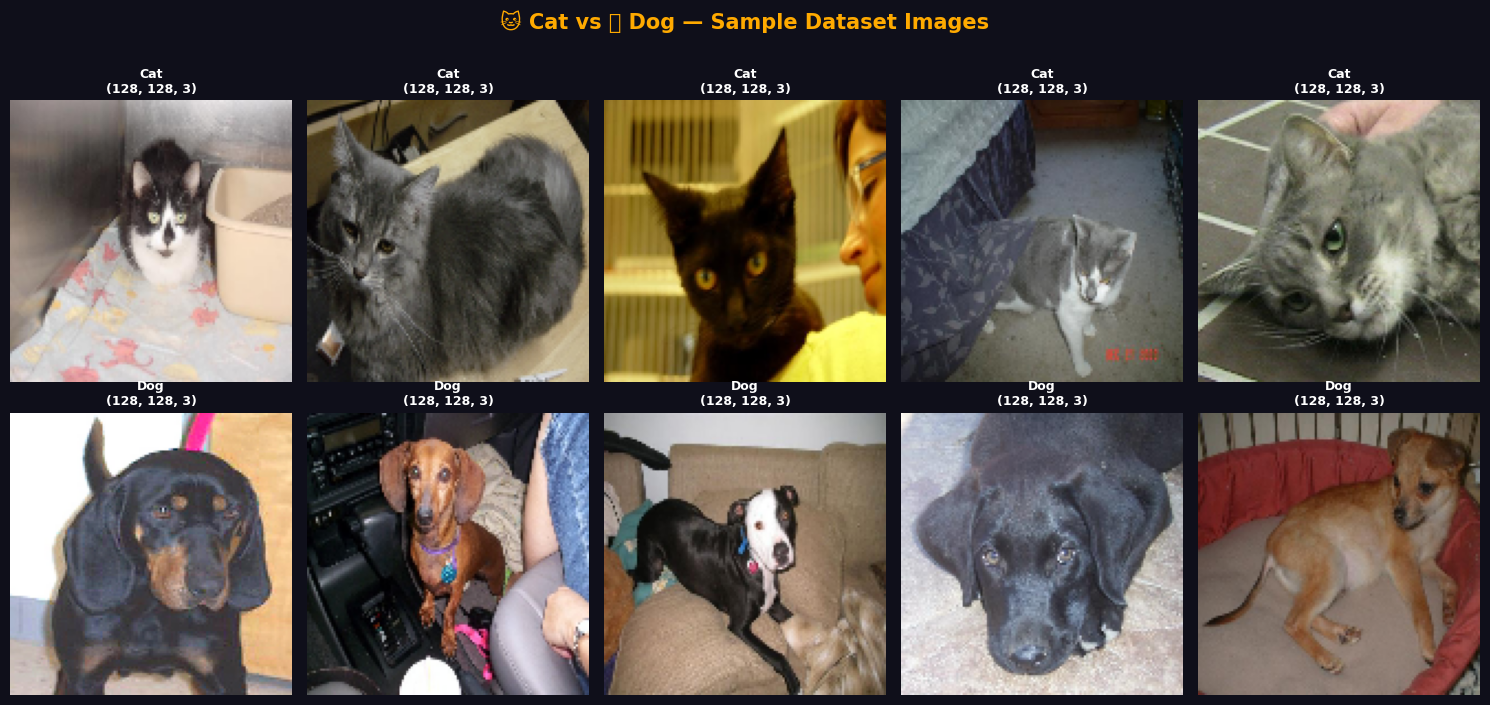


📐 Image Properties:
  shape   = (128, 128, 3)  (Height × Width × Channels)
  Height  = 128 pixels
  Width   = 128 pixels
  Channels= 3  (R, G, B)
  Values  = 49,152 total numbers per image


In [ ]:
# ============================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================

def show_samples(images, labels, categories, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 7))
    fig.patch.set_facecolor('#0f0f1a')

    for row, (cat_idx, cat_name) in enumerate(enumerate(categories)):
        idxs = np.where(labels == cat_idx)[0]
        if len(idxs) == 0:
            continue
        sel = np.random.choice(idxs, min(n, len(idxs)), replace=False)
        for col, idx in enumerate(sel):
            ax = axes[row, col]
            ax.imshow(images[idx])
            ax.set_title(f'{cat_name}\n{images[idx].shape}',
                         fontsize=9, color='white', fontweight='bold')
            ax.axis('off')
            border = '#00aaff' if cat_idx == 0 else '#ff6600'
            for spine in ax.spines.values():
                spine.set_edgecolor(border); spine.set_linewidth(2)

    plt.suptitle('🐱 Cat vs 🐶 Dog — Sample Dataset Images',
                 fontsize=15, color='#ffaa00', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    img = images[0]
    print(f"\n📐 Image Properties:")
    print(f"  shape   = {img.shape}  (Height × Width × Channels)")
    print(f"  Height  = {img.shape[0]} pixels")
    print(f"  Width   = {img.shape[1]} pixels")
    print(f"  Channels= {img.shape[2]}  (R, G, B)")
    print(f"  Values  = {img.size:,} total numbers per image")

show_samples(images, labels, CATEGORIES)

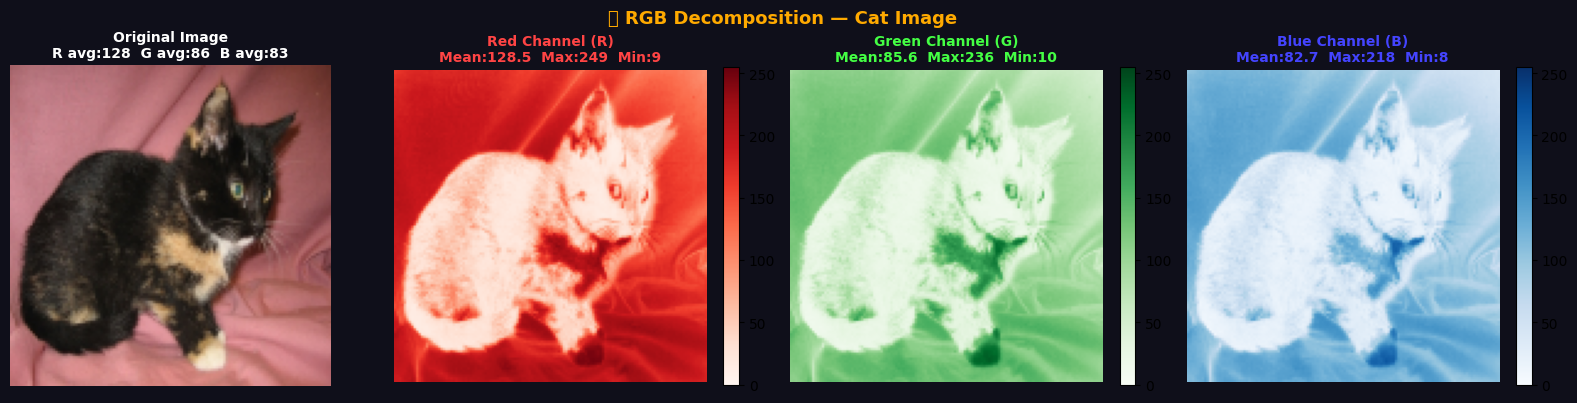

In [ ]:
# ============================================================
# VISUALIZE RGB CHANNELS
# ============================================================

def show_rgb_channels(image, title="Sample Image"):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor('#0f0f1a')

    channel_info = [
        ('Original Image',    None,     'white'),
        ('Red Channel (R)',   'Reds',   '#ff4444'),
        ('Green Channel (G)', 'Greens', '#44ff44'),
        ('Blue Channel (B)',  'Blues',  '#4444ff'),
    ]

    for i, (name, cmap, color) in enumerate(channel_info):
        ax = axes[i]
        ax.set_facecolor('#1a1a2e')
        if i == 0:
            ax.imshow(image)
            stats = f"R avg:{image[:,:,0].mean():.0f}  G avg:{image[:,:,1].mean():.0f}  B avg:{image[:,:,2].mean():.0f}"
            ax.set_title(f'{name}\n{stats}', color='white', fontsize=10, fontweight='bold')
        else:
            ch = image[:, :, i-1]
            im = ax.imshow(ch, cmap=cmap, vmin=0, vmax=255)
            ax.set_title(f'{name}\nMean:{ch.mean():.1f}  Max:{ch.max()}  Min:{ch.min()}',
                         color=color, fontsize=10, fontweight='bold')
            plt.colorbar(im, ax=ax, fraction=0.046)
        ax.axis('off')

    plt.suptitle(f'🎨 RGB Decomposition — {title}',
                 fontsize=13, color='#ffaa00', fontweight='bold')
    plt.tight_layout()
    plt.show()

show_rgb_channels(images[0], title=f"{CATEGORIES[labels[0]]} Image")

---
    # 🔷 SECTION 4: Image Preprocessing

    ---

    ## Preprocessing Pipeline:
    ```
    Raw Image (any size)
      ↓
    [Resize to 128×128]        → Uniform dimensions
      ↓
    [Normalize ÷ 255]          → Values 0–255 → 0.0–1.0
      ↓
    [Train/Test Split (80/20)] → 80% train, 20% test
      ↓
    [Validation Split (20%)]   → 20% of train = validation
      ↓
    [Data Augmentation]        → Flip, rotate, zoom
      ↓
    [Batch of 32]              → Feed to neural network
    ```

    ---

    ## 🔢 Why Normalize? (÷ 255)

    | Property | Before | After |
    |---------|--------|-------|
    | Range | 0–255 | 0.0–1.0 |
    | Data type | uint8 | float32 |
    | Gradient size | Large (unstable) | Small (stable) |
    | Training speed | Slow | Fast |

    **Mathematical reason:** Gradient descent works better with small, consistent input values. Large values cause large gradients → training oscillates and diverges.

    ---

    ## 📊 Train-Test-Validation Split

    ```
    Full Dataset (1000 images)
    │
    ├── Training Set (640 = 64%)     ← Model learns here
    ├── Validation Set (160 = 16%)   ← Tuning monitor
    └── Test Set (200 = 20%)         ← Final report card
    ```

    ---

    ## 🎲 Data Augmentation

    | Technique | What it creates |
    |-----------|----------------|
    | Horizontal flip | Mirror image |
    | Rotation (±20°) | Tilted version |
    | Zoom (±20%) | Zoomed in/out |
    | Shift (20%) | Moved position |
    | Brightness | Darker/lighter |
    

In [ ]:
# ============================================================
# SECTION 4: PREPROCESSING
# ============================================================

# STEP 1: Normalize
print("STEP 1: Normalize pixel values (÷ 255)")
images_norm = images.astype(np.float32) / 255.0
print(f"  Before: min={images.min()}, max={images.max()}, dtype={images.dtype}")
print(f"  After : min={images_norm.min():.3f}, max={images_norm.max():.3f}, dtype={images_norm.dtype}")

# STEP 2: Train/Test split
print("\nSTEP 2: Train / Test split (80 / 20)")
X_train, X_test, y_train, y_test = train_test_split(
  images_norm, labels,
  test_size=0.20, random_state=42, stratify=labels
)
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")

# STEP 3: Validation split (from train)
print("\nSTEP 3: Validation split (20% of train)")
X_train_f, X_val, y_train_f, y_val = train_test_split(
  X_train, y_train,
  test_size=0.20, random_state=42, stratify=y_train
)
print(f"  Final train : {X_train_f.shape}")
print(f"  Validation  : {X_val.shape}")
print(f"  Test        : {X_test.shape}")

# Convert labels to float32 (required by binary_crossentropy)
y_train_f = y_train_f.astype(np.float32)
y_val     = y_val.astype(np.float32)
y_test_f  = y_test.astype(np.float32)

print("\n" + "="*55)
print("📊 FINAL DATASET SPLIT")
print("="*55)
print(f"{'Set':<14} {'Images':<10} {'Cats':<8} {'Dogs':<8} {'%'}")
print("-"*50)
for name, X, y in [('Train', X_train_f, y_train_f), ('Val', X_val, y_val), ('Test', X_test, y_test_f)]:
  cats = int(np.sum(y==0)); dogs = int(np.sum(y==1))
  pct  = len(X)/len(images)*100
  print(f"{name:<14} {len(X):<10} {cats:<8} {dogs:<8} {pct:.1f}%")
print("="*55)


STEP 1: Normalize pixel values (÷ 255)
  Before: min=0, max=255, dtype=uint8
  After : min=0.000, max=1.000, dtype=float32

STEP 2: Train / Test split (80 / 20)
  Train: (3197, 128, 128, 3)  |  Test: (800, 128, 128, 3)

STEP 3: Validation split (20% of train)
  Final train : (2557, 128, 128, 3)
  Validation  : (640, 128, 128, 3)
  Test        : (800, 128, 128, 3)

📊 FINAL DATASET SPLIT
Set            Images     Cats     Dogs     %
--------------------------------------------------
Train          2557       1288     1269     64.0%
Val            640        323      317      16.0%
Test           800        403      397      20.0%


In [ ]:
from IPython.display import HTML

aug_html = """
<html><head><style>
body{background:#0f0f1a;color:white;font-family:Arial;padding:20px;text-align:center;}
h2{color:#ffaa00;}
.wrap{display:flex;flex-wrap:wrap;gap:18px;justify-content:center;margin-top:15px;}
.card{background:#1a1a2e;border-radius:10px;padding:12px;width:175px;}
canvas{border-radius:6px;}
.label{color:#aaffaa;font-size:12px;margin-top:6px;font-weight:bold;}
.sub{color:#888;font-size:10px;margin-top:3px;}
button{background:#00aaff;color:#fff;border:none;padding:9px 22px;border-radius:7px;
     cursor:pointer;font-size:13px;margin:5px;}
button:hover{background:#0077cc;}
</style></head>
<body>
<h2>🎲 Data Augmentation — More Training Data from the Same Images</h2>
<div><button onclick="drawAll()">▶ Redraw Augmentations</button></div>
<div class="wrap" id="wrap"></div>
<script>
const augments=[
{name:'Original',   desc:'No transformation',          tx:0,ty:0,sx:1, sy:1,rot:0,  border:'#00aaff'},
{name:'Flip H',     desc:'Horizontal mirror',           tx:0,ty:0,sx:-1,sy:1,rot:0,  border:'#ff6600'},
{name:'Rotate +15°',desc:'Slight clockwise rotation',   tx:0,ty:0,sx:1, sy:1,rot:15, border:'#aa44ff'},
{name:'Rotate -15°',desc:'Counter-clockwise rotation',  tx:0,ty:0,sx:1, sy:1,rot:-15,border:'#44aaff'},
{name:'Zoom In',    desc:'20% zoom',                    tx:0,ty:0,sx:1.2,sy:1.2,rot:0,border:'#00ff88'},
{name:'Shift Right',desc:'Horizontal position shift',   tx:20,ty:0,sx:1,sy:1,rot:0,  border:'#ffff00'},
{name:'Shift Down', desc:'Vertical position shift',     tx:0,ty:20,sx:1,sy:1,rot:0,  border:'#ff4488'},
{name:'Brightness', desc:'Simulated lighting change',   tx:0,ty:0,sx:1, sy:1,rot:0,  border:'#ffaa00'},
];

const wrap=document.getElementById('wrap');
const canvases=[];

augments.forEach((aug,i)=>{
const card=document.createElement('div');
card.className='card';card.style.borderLeft='3px solid '+aug.border;
const c=document.createElement('canvas');
c.width=150;c.height=150;canvases.push({c,aug});
card.innerHTML='<div style="color:'+aug.border+';font-weight:bold;font-size:12px">'+aug.name+'</div>';
card.appendChild(c);
card.innerHTML+='<div class="sub">'+aug.desc+'</div>';
wrap.appendChild(card);
});

function drawCat(ctx,aug){
ctx.save();
ctx.fillStyle='#0f0f1a';ctx.fillRect(-200,-200,600,600);
if(aug.name==='Brightness'){ctx.filter='brightness(1.6)';}
ctx.translate(75+aug.tx,75+aug.ty);
ctx.scale(aug.sx,aug.sy);
ctx.rotate(aug.rot*Math.PI/180);
ctx.translate(-75,-75);
ctx.fillStyle='#c8a87a';
ctx.beginPath();ctx.arc(75,85,55,0,Math.PI*2);ctx.fill();
ctx.beginPath();ctx.moveTo(25,45);ctx.lineTo(10,10);ctx.lineTo(50,35);ctx.closePath();ctx.fill();
ctx.beginPath();ctx.moveTo(125,45);ctx.lineTo(140,10);ctx.lineTo(100,35);ctx.closePath();ctx.fill();
ctx.fillStyle='#2ecc71';
ctx.beginPath();ctx.arc(58,78,10,0,Math.PI*2);ctx.fill();
ctx.beginPath();ctx.arc(92,78,10,0,Math.PI*2);ctx.fill();
ctx.fillStyle='#000';
ctx.beginPath();ctx.arc(58,78,4,0,Math.PI*2);ctx.fill();
ctx.beginPath();ctx.arc(92,78,4,0,Math.PI*2);ctx.fill();
ctx.fillStyle='#ff9999';
ctx.beginPath();ctx.arc(75,98,6,0,Math.PI*2);ctx.fill();
ctx.strokeStyle='#c8a87a';ctx.lineWidth=2;
ctx.beginPath();ctx.moveTo(65,106);ctx.quadraticCurveTo(75,115,85,106);ctx.stroke();
ctx.restore();
}

function drawAll(){canvases.forEach(({c,aug})=>{drawCat(c.getContext('2d'),aug);});}
drawAll();
</script></body></html>
"""
HTML(aug_html)

---
    # 🔷 SECTION 5: What is an Image?

    ---

    ## 🔲 What is a Pixel?

    A **pixel** ("picture element") is the smallest unit of a digital image. Every image is a **grid of pixels**.

    ---

    ## 📐 Image as a 3D Matrix

    A color image has **3 dimensions**: Height × Width × Channels

    ```
    Image shape: (Height, Width, 3)

    Red channel:          Green channel:        Blue channel:
    [255, 120, 200]       [ 80, 100,  60]       [ 40,  30,  20]
    [180,  90, 150]       [ 70,  85,  50]       [ 35,  25,  15]
    [220, 100, 180]       [ 90,  95,  70]       [ 45,  35,  25]
    ```

    ---

    ## 🎨 RGB Color Examples

    | (R, G, B) | Color |
    |-----------|-------|
    | (255, 0, 0) | Red |
    | (0, 255, 0) | Green |
    | (0, 0, 255) | Blue |
    | (255, 255, 0) | Yellow |
    | (0, 0, 0) | Black |
    | (255, 255, 255) | White |
    

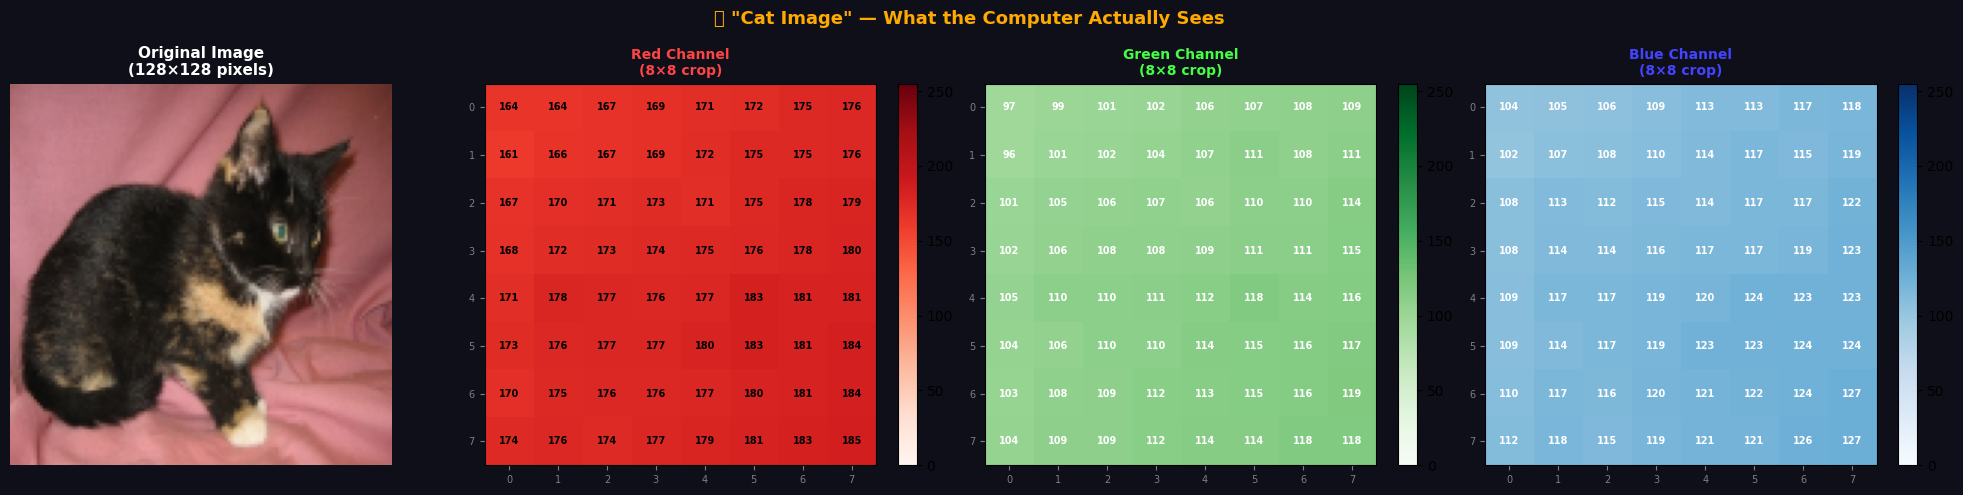

Image shape: (128, 128, 3)
  → (128h × 128w × 3c) = 49,152 total numbers

4 sample pixels (R, G, B):
  (0,0) → R=164  G=97  B=104
  (0,1) → R=164  G=99  B=105
  (1,0) → R=161  G=96  B=102
  (1,1) → R=166  G=101  B=107


In [ ]:
# ============================================================
# SECTION 5: IMAGE AS MATRIX
# ============================================================

def visualize_as_matrix(image, crop=8, title=""):
    """Show image + its pixel value matrices (R, G, B channels)."""
    crop_img = image[:crop, :crop, :]  # top-left crop for readability

    fig = plt.figure(figsize=(20, 5))
    fig.patch.set_facecolor('#0f0f1a')

    # Original
    ax0 = fig.add_subplot(1, 4, 1)
    ax0.imshow(image)
    ax0.set_title('Original Image\n(128×128 pixels)',
                  color='white', fontsize=11, fontweight='bold')
    ax0.axis('off')

    channel_info = [('Red Channel',   'Reds',   '#ff4444', 1),
                    ('Green Channel', 'Greens', '#44ff44', 2),
                    ('Blue Channel',  'Blues',  '#4444ff', 3)]

    for (cname, cmap, ccolor, cidx) in channel_info:
        ax = fig.add_subplot(1, 4, cidx + 1)
        ch = crop_img[:, :, cidx - 1]
        im = ax.imshow(ch, cmap=cmap, vmin=0, vmax=255, aspect='auto')
        for r in range(crop):
            for c in range(crop):
                v = ch[r, c]
                ax.text(c, r, str(v), ha='center', va='center',
                        fontsize=7, color='black' if v > 150 else 'white',
                        fontweight='bold')
        ax.set_title(f'{cname}\n({crop}×{crop} crop)',
                     color=ccolor, fontsize=10, fontweight='bold')
        ax.set_xticks(range(crop)); ax.set_yticks(range(crop))
        ax.tick_params(colors='gray', labelsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(f'🖼️ "{title}" — What the Computer Actually Sees',
                 fontsize=13, color='#ffaa00', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Image shape: {image.shape}")
    print(f"  → ({image.shape[0]}h × {image.shape[1]}w × {image.shape[2]}c) = {image.size:,} total numbers")
    print(f"\n4 sample pixels (R, G, B):")
    for r in range(2):
        for c in range(2):
            print(f"  ({r},{c}) → R={image[r,c,0]}  G={image[r,c,1]}  B={image[r,c,2]}")

visualize_as_matrix(images[0], title=f"{CATEGORIES[labels[0]]} Image")

---
    # 🔷 SECTION 6: How CNN Works — The Full Pipeline

    ---

    ## 🏗️ Complete CNN Data Flow

    ```
    ┌─────────────────────────────────────────────────────┐
    │  INPUT IMAGE (128 × 128 × 3)  =  49,152 numbers    │
    └────────────────────┬────────────────────────────────┘
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  CONV2D (32 filters, 3×3)                           │
    │  Scans image for edges, textures, patterns          │
    │  Output: 128 × 128 × 32 = 524,288 values           │
    └────────────────────┬────────────────────────────────┘
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  RELU ACTIVATION: max(0, x)                         │
    │  Removes negative values — adds non-linearity       │
    └────────────────────┬────────────────────────────────┘
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  MAX POOLING (2×2)                                  │
    │  Keeps max value per 2×2 region                     │
    │  Output: 64 × 64 × 32  (half the size)             │
    └────────────────────┬────────────────────────────────┘
                       ↓
              [Repeat conv blocks]
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  FLATTEN → 1D vector (e.g. 8192 values)             │
    └────────────────────┬────────────────────────────────┘
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  DENSE (128 neurons, ReLU)                          │
    └────────────────────┬────────────────────────────────┘
                       ↓
    ┌─────────────────────────────────────────────────────┐
    │  OUTPUT (1 neuron, Sigmoid)                         │
    │  < 0.5 = Cat 🐱   ≥ 0.5 = Dog 🐶                  │
    └─────────────────────────────────────────────────────┘
    ```

    ---

    ## What Each Depth Learns

    | Layer Depth | What it Detects |
    |-------------|----------------|
    | Layer 1 (early) | Edges, lines, color gradients |
    | Layer 2–3 | Corners, curves, simple shapes |
    | Layer 4–5 | Eyes, ears, fur texture |
    | Deep layers | "Cat-ness" vs "Dog-ness" |
    

In [ ]:
from IPython.display import HTML

pipeline_html = """
<html><head><style>
body{background:#0f0f1a;color:white;font-family:Arial;padding:20px;text-align:center;}
h2{color:#ffaa00;}
.pipeline{display:flex;align-items:center;justify-content:center;flex-wrap:wrap;
        gap:4px;margin:20px auto;max-width:1000px;}
.box{background:#1a1a2e;border-radius:10px;padding:10px 8px;text-align:center;
   min-width:95px;cursor:pointer;transition:all .3s;}
.box:hover{transform:translateY(-5px);box-shadow:0 6px 20px rgba(0,170,255,.4);}
.name{font-size:11px;font-weight:bold;}
.shape{font-size:9px;color:#aaa;margin-top:3px;}
.arr{font-size:22px;color:#00aaff;}
#info{background:#1a1a2e;border:2px solid #00aaff;border-radius:12px;padding:18px;
    margin:20px auto;max-width:650px;}
#ititle{color:#ffaa00;font-size:17px;font-weight:bold;}
#idesc{color:#ccc;margin-top:10px;font-size:14px;line-height:1.6;}
</style></head>
<body>
<h2>ဒဲး CNN Architecture — Click Any Layer to Learn More</h2>
<div class="pipeline" id="pl"></div>
<div id="info"><div id="ititle">Click a layer above ↑</div>
<div id="idesc">Each layer transforms the data and extracts increasingly complex features.</div></div>
<script>
const layers=[
{n:'Input',s:'128%128%3',c:'#00aaff',
 d:'The raw RGB image. Each pixel has 3 values (R,G,B) from 0–255. Total: 49,152 numbers entering the network.'},
{n:'Conv2D\n32 filters',s:'128%128%32',c:'#ff6600',
 d:'32 learnable 3%3 filters slide across the image. Each filter detects one specific pattern (horizontal edges, colors, etc). Output: 32 feature maps.'},
{n:'ReLU',s:'128%128%32',c:'#aa44ff',
 d:'ReLU(x) = max(0, x). Sets all negative feature map values to 0. This non-linearity allows the network to learn complex, non-linear patterns.'},
{n:'MaxPool\n2%2',s:'64%64%32',c:'#00ff88',
 d:'Divides each feature map into 2%2 blocks, keeping only the maximum. Reduces spatial size by half (128→64) while preserving strongest signals.'},
{n:'Conv2D\n64 filters',s:'64%64%64',c:'#ff6600',
 d:'64 filters now learn more complex patterns by combining features from previous layer — simple edges combine into curves, corners, textures.'},
{n:'ReLU',s:'64%64%64',c:'#aa44ff',
 d:'Another non-linearity after the second convolution layer.'},
{n:'MaxPool\n2%2',s:'32%32%64',c:'#00ff88',
 d:'Reduces 64%64 → 32%32. Network is now 4% smaller spatially but 64% richer in channels.'},
{n:'Conv2D\n64 filters',s:'32%32%64',c:'#ff6600',
 d:'Third conv block. Now detects complex structures: ear shapes, eye regions, fur density.'},
{n:'MaxPool\n2%2',s:'16%16%64',c:'#00ff88',
 d:'Final pooling. Spatial resolution 16%16, 64 channels.'},
{n:'Flatten',s:'16384',c:'#ffff00',
 d:'Converts 3D tensor (16%16%64=16,384 values) into 1D vector. This prepares data for Dense layers. No parameters are learned here.'},
{n:'Dense\n128',s:'128',c:'#ff4488',
 d:'128 fully-connected neurons. Each neuron receives all 16,384 inputs and learns complex feature combinations. Parameters: 16,384%128 + 128 = ~2.1M.'},
{n:'Output\nSigmoid',s:'1',c:'#ffffff',
 d:'Single neuron with Sigmoid. Output 0.0–1.0. Under 0.5 = Cat, 0.5 or above = Dog. Confidence = distance from 0.5.'},
];

const pl=document.getElementById('pl');
const it=document.getElementById('ititle');
const id=document.getElementById('idesc');

layers.forEach((l,i)=>{
if(i>0){const a=document.createElement('div');a.className='arr';a.textContent='→';pl.appendChild(a);}
const b=document.createElement('div');b.className='box';
b.style.borderLeft='4px solid '+l.c;
b.innerHTML='<div class="name" style="color:'+l.c+'">'+l.n.replace("\n","<br>")+'</div>'
           +'<div class="shape">'+l.s+'</div>';
b.onclick=()=>{
  it.textContent=l.n.replace("\n"," ");it.style.color=l.c;id.textContent=l.d;
  document.querySelectorAll('.box').forEach(x=>x.style.background='#1a1a2e');
  b.style.background=l.c+'22';
};
pl.appendChild(b);
});
</script></body></html>
"""
HTML(pipeline_html)

---
    # 🔷 SECTION 7: Convolution — The Heart of CNN

    ---

    ## What is Convolution?

    A small **filter/kernel** slides over the input image and computes **dot products** at each position.

    > **Real-World Analogy:**  
    > Imagine scanning a photo with a magnifying glass looking for a specific pattern (e.g., a cat's ear shape). Each stop of the magnifying glass = one convolution step. The collection of highlights = the feature map.

    ---

    ## Key Terms

    | Term | Definition |
    |------|-----------|
    | **Kernel/Filter** | Small weight matrix (e.g., 3×3) that detects one pattern |
    | **Stride** | How many pixels to move the kernel each step |
    | **Padding** | Zeros added around the image edges |
    | **Feature Map** | Output of one convolution — shows where the pattern exists |

    ---

    ## Mathematical Formula

    $$\text{Output}[i,j] = \sum_{m=0}^{K-1} \sum_{n=0}^{K-1} \text{Input}[i+m,\; j+n] \times \text{Kernel}[m,n] + b$$

    ---

    ## Output Size Formula

    $$\text{Output Size} = \frac{\text{Input} - \text{Kernel}}{\text{Stride}} + 1$$

    **Example:** Input=5, Kernel=3, Stride=1 → (5-3)/1+1 = **3**

    ---

    ## Step-by-Step Calculation (5×5 input, 3×3 kernel)

    **Input:**
    ```
    1  2  3  4  5
    5  6  7  8  9
    9  8  7  6  5
    5  4  3  2  1
    1  2  3  4  5
    ```

    **Edge Detector Kernel:**
    ```
    -1  -1  -1
    -1   8  -1
    -1  -1  -1
    ```

    **Position (0,0):** patch × kernel → sum:
    ```
    1×(-1) + 2×(-1) + 3×(-1)
    5×(-1) + 6×8   + 7×(-1)  = -1-2-3-5+48-7-9-8-7 = 6
    9×(-1) + 8×(-1) + 7×(-1)
    ```
    

In [ ]:
from IPython.display import HTML

conv_html = """
<html><head><style>
body{background:#0f0f1a;color:white;font-family:Arial;padding:20px;}
h2{color:#ffaa00;text-align:center;}
.main{display:flex;gap:30px;justify-content:center;align-items:flex-start;flex-wrap:wrap;}
.section{text-align:center;}
h3{color:#00aaff;}
.grid{display:inline-grid;gap:3px;}
.cell{width:48px;height:48px;display:flex;align-items:center;justify-content:center;
    font-weight:bold;font-size:13px;border-radius:5px;border:2px solid transparent;
    transition:all .3s;}
.inp{background:#1a3a5c;color:white;}
.ker{background:#2d1a5c;color:#ffaa00;}
.out{background:#1a5c2d;color:white;}
.hl{border:3px solid #ff6600!important;background:#ff660040!important;}
.outhl{border:3px solid #00ff88!important;background:#00ff8830!important;}
.op{font-size:32px;color:#00aaff;padding-top:80px;}
#info{background:#1a1a2e;border:2px solid #00aaff;border-radius:10px;padding:16px;
    max-width:520px;margin:18px auto;text-align:center;}
#formula{color:#ffaa00;font-size:15px;font-family:monospace;word-break:break-all;}
#stepinfo{color:#aaffaa;font-size:13px;margin-top:8px;}
.ctrl{text-align:center;margin:12px;}
button{background:#ff6600;color:white;border:none;padding:9px 22px;margin:4px;
     border-radius:7px;cursor:pointer;font-size:13px;}
button:hover{background:#cc4400;}
.lbl{color:#888;font-size:11px;margin-top:6px;}
</style></head>
<body>
<h2>⚡ Convolution — Animated Step-by-Step</h2>
<div class="ctrl">
<button onclick="startA()">▶ Auto Play</button>
<button onclick="nextStep()">⏭ Next Step</button>
<button onclick="resetA()">↺ Reset</button>
</div>
<div class="main">
<div class="section"><h3>Input (5×5)</h3>
  <div class="grid" id="ig" style="grid-template-columns:repeat(5,48px)"></div>
  <div class="lbl">Image pixels</div></div>
<div class="op">✱</div>
<div class="section"><h3>Kernel (3×3)</h3>
  <div class="grid" id="kg" style="grid-template-columns:repeat(3,48px)"></div>
  <div class="lbl">Learned filter</div></div>
<div class="op">=</div>
<div class="section"><h3>Output (3×3)</h3>
  <div class="grid" id="og" style="grid-template-columns:repeat(3,48px)"></div>
  <div class="lbl">Feature map</div></div>
</div>
<div id="info">
<div id="formula">Press Start or Next Step to begin!</div>
<div id="stepinfo">The kernel slides across the image computing dot products.</div>
</div>
<script>
const inp=[[1,2,3,4,5],[5,6,7,8,9],[9,8,7,6,5],[5,4,3,2,1],[1,2,3,4,5]];
const ker=[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]];
let step=0,timer=null;
const positions=[];for(let r=0;r<3;r++)for(let c=0;c<3;c++)positions.push([r,c]);

function gc(v){
const n=Math.min(Math.max(v,1),9);
const t=['#0a1a2e','#0d2a4a','#1040706','#1a5580','#2080a0','#c0a070','#d0b080','#e0c090','#f0d0a0'][Math.floor((n-1)/1)];
const i=Math.round(26+(n/9)*80);return`rgb(${i},${Math.round(i*1.2)},${Math.round(i*1.8)})`;
}

function init(){
const ig=document.getElementById('ig');ig.innerHTML='';
inp.flat().forEach((v,i)=>{
  const d=document.createElement('div');d.className='cell inp';d.id='in'+i;d.textContent=v;
  d.style.background=gc(v);ig.appendChild(d);
});
const kg=document.getElementById('kg');kg.innerHTML='';
ker.flat().forEach(v=>{
  const d=document.createElement('div');d.className='cell ker';
  d.textContent=v;kg.appendChild(d);
});
const og=document.getElementById('og');og.innerHTML='';
for(let i=0;i<9;i++){
  const d=document.createElement('div');d.className='cell out';d.id='out'+i;d.textContent='?';og.appendChild(d);
}
}

function compute(r,c){
let s=0,terms=[];
for(let kr=0;kr<3;kr++)for(let kc=0;kc<3;kc++){
  const iv=inp[r+kr][c+kc],kv=ker[kr][kc];s+=iv*kv;terms.push(`${iv}×(${kv})`);
}
return{s,terms};
}

function hl(r,c,oi){
document.querySelectorAll('.hl,.outhl').forEach(e=>{e.classList.remove('hl','outhl');});
for(let kr=0;kr<3;kr++)for(let kc=0;kc<3;kc++){
  const el=document.getElementById('in'+((r+kr)*5+(c+kc)));if(el)el.classList.add('hl');
}
const{s,terms}=compute(r,c);
const oe=document.getElementById('out'+oi);
if(oe){oe.textContent=s;oe.classList.add('outhl');
       const norm=Math.min(Math.max(s,-20),60);
       const g=Math.round((norm+20)/80*200);
       oe.style.background=`rgb(0,${g},50)`;}
document.getElementById('formula').textContent='Sum = '+terms.slice(0,5).join(' + ')+(terms.length>5?' + ...':'')+'= '+s;
document.getElementById('stepinfo').textContent='Step '+(oi+1)+'/9 — Kernel at ('+r+','+c+') → Output['+Math.floor(oi/3)+']['+oi%3+'] = '+s;
}

function nextStep(){if(step>=9)step=0;const[r,c]=positions[step];hl(r,c,step);step++;}
function startA(){if(timer){clearInterval(timer);timer=null;return;}step=0;timer=setInterval(()=>{if(step>=9){clearInterval(timer);timer=null;return;}nextStep();},1100);}
function resetA(){if(timer){clearInterval(timer);timer=null;}step=0;init();document.getElementById('formula').textContent='Resetted — press Start!';document.getElementById('stepinfo').textContent='';}
init();
</script></body></html>
"""
HTML(conv_html)

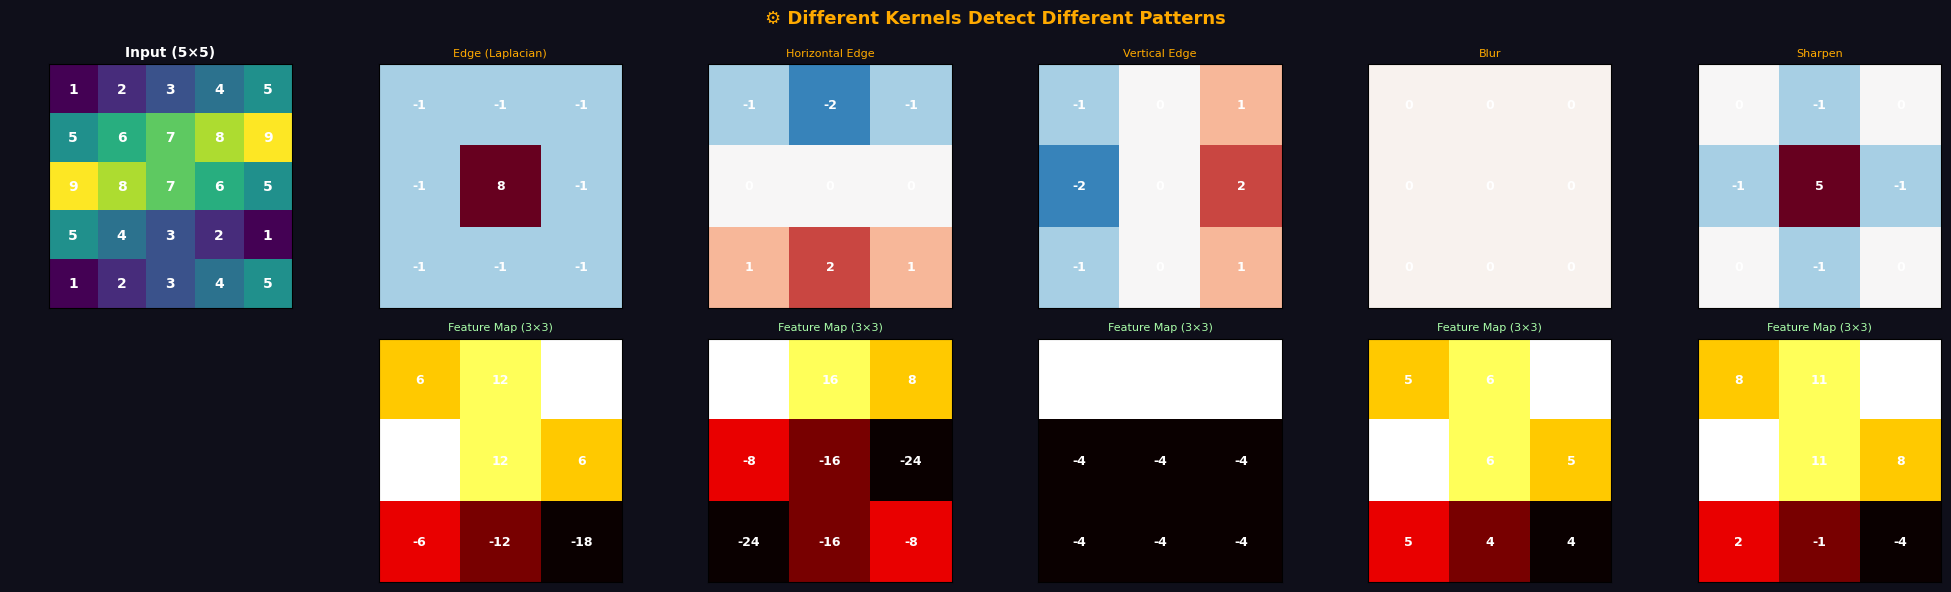

📐 Key formula: Output Size = (Input - Kernel) / Stride + 1
   Example:  (5 - 3) / 1 + 1 = 3  →  output is 3×3

✅ This is exactly what tf.keras.layers.Conv2D does!


In [ ]:
# ============================================================
# SECTION 7: CONVOLUTION — NUMPY IMPLEMENTATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def manual_conv2d(img_2d, kernel, stride=1, padding=0):
    """
    Manual 2D convolution — exactly what tf.keras.layers.Conv2D does internally.

    Parameters:  img_2d (H×W), kernel (K×K), stride, padding
    Returns:     feature_map (out_H × out_W)
    """
    if padding > 0:
        img_2d = np.pad(img_2d, padding, mode='constant', constant_values=0)
    H, W = img_2d.shape
    K = kernel.shape[0]
    out_H = (H - K) // stride + 1
    out_W = (W - K) // stride + 1
    fm = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = img_2d[i*stride:i*stride+K, j*stride:j*stride+K]
            fm[i, j] = np.sum(patch * kernel)
    return fm

# Test image and kernels
test_img = np.array([
    [1,2,3,4,5],[5,6,7,8,9],[9,8,7,6,5],[5,4,3,2,1],[1,2,3,4,5]
], dtype=np.float32)

kernels = {
    'Edge (Laplacian)': np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float32),
    'Horizontal Edge':  np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    'Vertical Edge':    np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    'Blur':             np.ones((3,3), dtype=np.float32)/9,
    'Sharpen':          np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}

fig, axes = plt.subplots(2, len(kernels)+1, figsize=(20, 6))
fig.patch.set_facecolor('#0f0f1a')

# Input
axes[0,0].set_facecolor('#1a1a2e')
axes[0,0].imshow(test_img, cmap='viridis', vmin=1, vmax=9)
axes[0,0].set_title('Input (5×5)', color='white', fontsize=10, fontweight='bold')
for r in range(5):
    for c in range(5):
        axes[0,0].text(c, r, str(int(test_img[r,c])), ha='center', va='center',
                       fontsize=10, color='white', fontweight='bold')
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])
axes[1,0].axis('off')

for col, (kname, kernel) in enumerate(kernels.items(), 1):
    # Kernel
    ax_k = axes[0, col]
    ax_k.imshow(kernel, cmap='RdBu_r', vmin=-3, vmax=3)
    ax_k.set_title(kname, color='#ffaa00', fontsize=8)
    for r in range(3):
        for c in range(3):
            ax_k.text(c, r, f'{kernel[r,c]:.0f}', ha='center', va='center',
                      fontsize=9, color='white', fontweight='bold')
    ax_k.set_xticks([]); ax_k.set_yticks([])

    # Feature map
    fm = manual_conv2d(test_img, kernel)
    ax_f = axes[1, col]
    ax_f.imshow(fm, cmap='hot')
    ax_f.set_title('Feature Map (3×3)', color='#aaffaa', fontsize=8)
    for r in range(3):
        for c in range(3):
            ax_f.text(c, r, f'{fm[r,c]:.0f}', ha='center', va='center',
                      fontsize=9, color='white', fontweight='bold')
    ax_f.set_xticks([]); ax_f.set_yticks([])

plt.suptitle('⚙️ Different Kernels Detect Different Patterns',
             fontsize=13, color='#ffaa00', fontweight='bold')
plt.tight_layout()
plt.show()

print("📐 Key formula: Output Size = (Input - Kernel) / Stride + 1")
print(f"   Example:  (5 - 3) / 1 + 1 = 3  →  output is 3×3")
print(f"\n✅ This is exactly what tf.keras.layers.Conv2D does!")

---
    # 🔷 SECTION 8: Weights & SECTION 9: Bias

    ---

    ## 🎯 What Are Weights?

    **Weights** are the learnable parameters of the network — numbers that get updated during training to minimize loss.

    $$\text{output} = \sum_i (\text{input}_i \times \text{weight}_i) + \text{bias}$$

    > **Analogy:** A talent show judge weights singing at 0.8, dancing at 0.3, and humor at 0.1. These are the "weights" determining the final score.

    ---

    ## 🎲 Weight Initialization Methods

    ### Random Initialization
    $$W \sim \mathcal{N}(0,\; 0.01)$$
    - Very small random values; simple but causes vanishing gradients in deep nets

    ### He Initialization (for ReLU — recommended)
    $$W \sim \mathcal{N}\left(0,\; \sqrt{\frac{2}{n_{\text{in}}}}\right)$$
    - Designed specifically for ReLU; prevents dying ReLU

    ### Xavier / Glorot (for Sigmoid/Tanh)
    $$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}},\; +\sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}}\right)$$

    ---

    ## ⚖️ What is Bias?

    **Bias** shifts the activation function. Without it, every line must pass through the origin.

    $$\text{output} = W \cdot x + b$$

    > **Analogy:** In y = mx + **b**, the bias b is the y-intercept. Without it, every line passes through (0,0) — very restrictive!
    

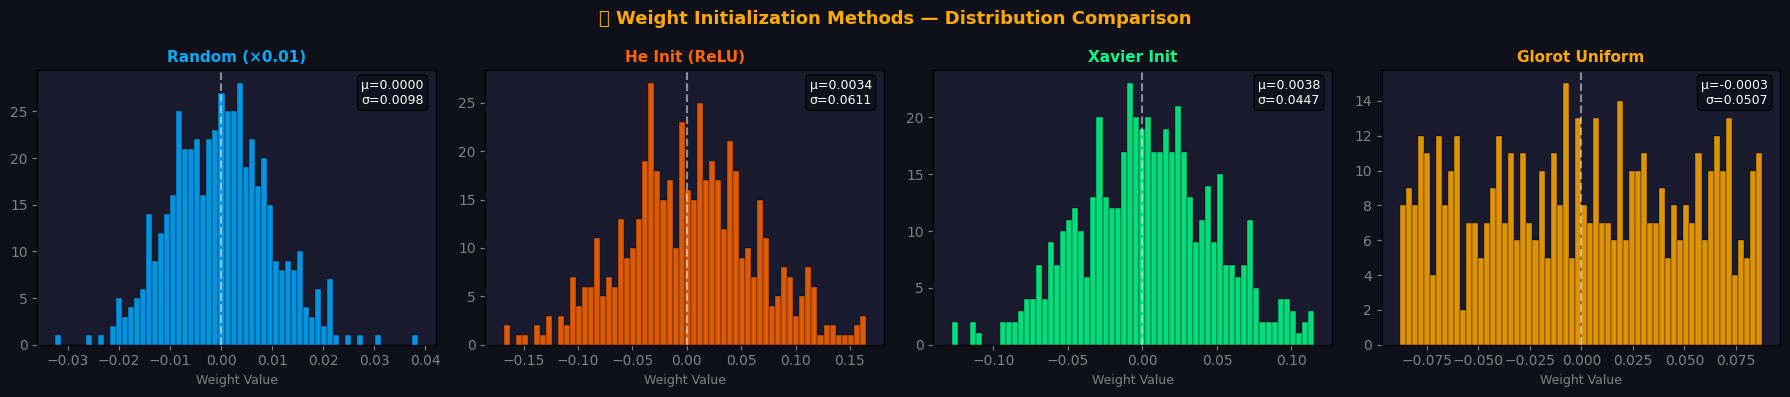

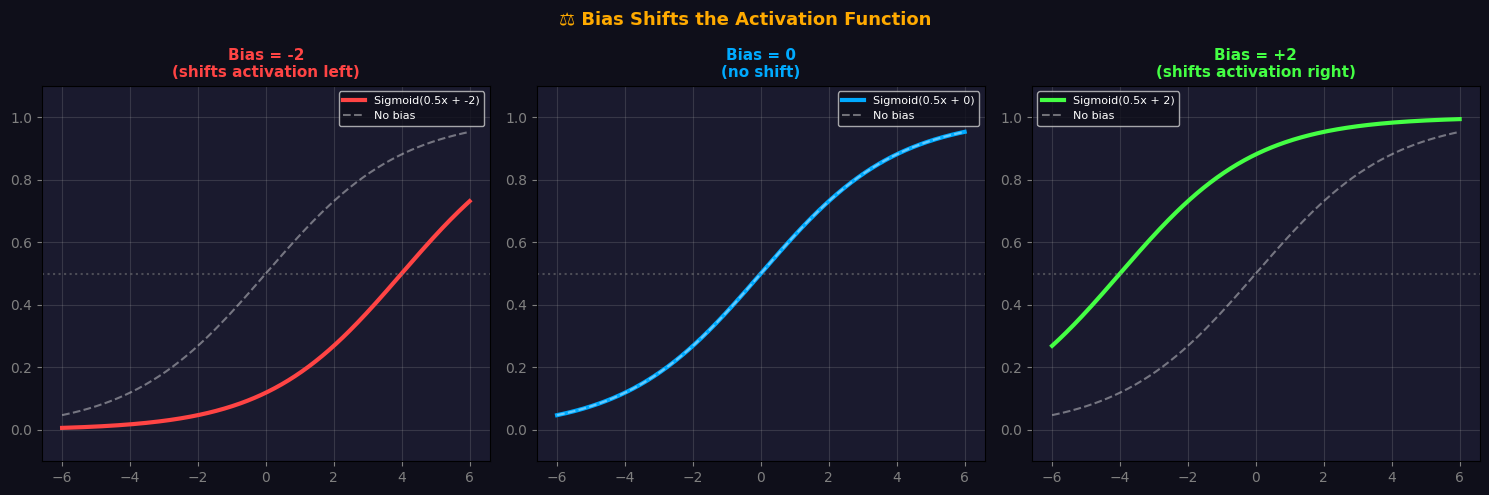

🔑 Summary:
  He Init:    Best for ReLU networks (prevents gradient vanishing)
  Xavier:     Best for Sigmoid/Tanh networks
  Bias:       Gives neurons the freedom to fire even when input=0


In [ ]:
# ============================================================
# SECTIONS 8-9: WEIGHTS AND BIAS VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_in = 512

init_methods = {
  'Random (×0.01)':    np.random.randn(n_in) * 0.01,
  'He Init (ReLU)':    np.random.randn(n_in) * np.sqrt(2.0 / n_in),
  'Xavier Init':       np.random.randn(n_in) * np.sqrt(1.0 / n_in),
  'Glorot Uniform':    np.random.uniform(-np.sqrt(6/(n_in+256)), np.sqrt(6/(n_in+256)), n_in),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#0f0f1a')
colors = ['#00aaff', '#ff6600', '#00ff88', '#ffaa00']

for idx, ((name, w), color) in enumerate(zip(init_methods.items(), colors)):
  ax = axes[idx]
  ax.set_facecolor('#1a1a2e')
  ax.hist(w, bins=60, color=color, alpha=0.85, edgecolor='black', linewidth=0.3)
  ax.axvline(0, color='white', linestyle='--', alpha=0.5)
  ax.set_title(name, color=color, fontsize=11, fontweight='bold')
  ax.set_xlabel('Weight Value', color='gray', fontsize=9)
  ax.tick_params(colors='gray')
  info = f'μ={w.mean():.4f}\nσ={w.std():.4f}'
  ax.text(0.97, 0.97, info, transform=ax.transAxes, color='white', fontsize=9,
          va='top', ha='right', bbox=dict(boxstyle='round', facecolor='#0f0f1a', alpha=0.8))

plt.suptitle('🎲 Weight Initialization Methods — Distribution Comparison',
           fontsize=13, color='#ffaa00', fontweight='bold')
plt.tight_layout()
plt.show()

# ── BIAS EFFECT ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')
x = np.linspace(-6, 6, 300)

for idx, (b, color, title) in enumerate([
  (-2, '#ff4444', 'Bias = -2\n(shifts activation left)'),
  (0,  '#00aaff', 'Bias = 0\n(no shift)'),
  (+2, '#44ff44', 'Bias = +2\n(shifts activation right)'),
]):
  ax = axes[idx]
  ax.set_facecolor('#1a1a2e')
  sig_b = 1 / (1 + np.exp(-(0.5*x + b)))
  sig_0 = 1 / (1 + np.exp(-0.5*x))
  ax.plot(x, sig_b, color=color, linewidth=3, label=f'Sigmoid(0.5x + {b})')
  ax.plot(x, sig_0, 'white', linewidth=1.5, linestyle='--', alpha=0.4, label='No bias')
  ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
  ax.set_title(title, color=color, fontsize=11, fontweight='bold')
  ax.set_ylim(-0.1, 1.1)
  ax.tick_params(colors='gray')
  ax.legend(fontsize=8, labelcolor='white', facecolor='#0f0f1a')
  ax.grid(True, alpha=0.2)

plt.suptitle('⚖️ Bias Shifts the Activation Function',
           fontsize=13, color='#ffaa00', fontweight='bold')
plt.tight_layout()
plt.show()

print("🔑 Summary:")
print("  He Init:    Best for ReLU networks (prevents gradient vanishing)")
print("  Xavier:     Best for Sigmoid/Tanh networks")
print("  Bias:       Gives neurons the freedom to fire even when input=0")

---
    # 🔷 SECTION 10: Activation Functions

    ---

    ## Why Do We Need Activation Functions?

    Without them, stacking layers is still just one linear function:

    ```
    Layer 1: y = W₁x + b₁
    Layer 2: y = W₂(W₁x + b₁) + b₂  =  (W₂W₁)x + constant
           → Still linear! No matter how many layers.
    ```

    Activation functions add **non-linearity** → the network can learn complex patterns.

    ---

    ## 1. Sigmoid: $\sigma(x) = \frac{1}{1+e^{-x}}$
    - Range: **(0, 1)** — great for probabilities
    - Used in: **output layer of binary classifiers**
    - Problem: Vanishing gradient for large |x|

    ## 2. Tanh: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
    - Range: **(-1, +1)** — zero-centered
    - Better than Sigmoid for hidden layers, still vanishing gradient

    ## 3. ReLU: $f(x) = \max(0, x)$
    - Range: **[0, ∞)** — most popular!
    - Fast, no vanishing gradient for positive x
    - Problem: "Dying ReLU" for x < 0

    ## 4. Leaky ReLU: $f(x) = x \text{ if } x>0 \text{ else } 0.01x$
    - Fixes dying ReLU: small slope for negatives

    ## 5. Softmax: $f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$
    - Converts scores to probabilities summing to 1.0
    - Used in **multi-class output layers**
    

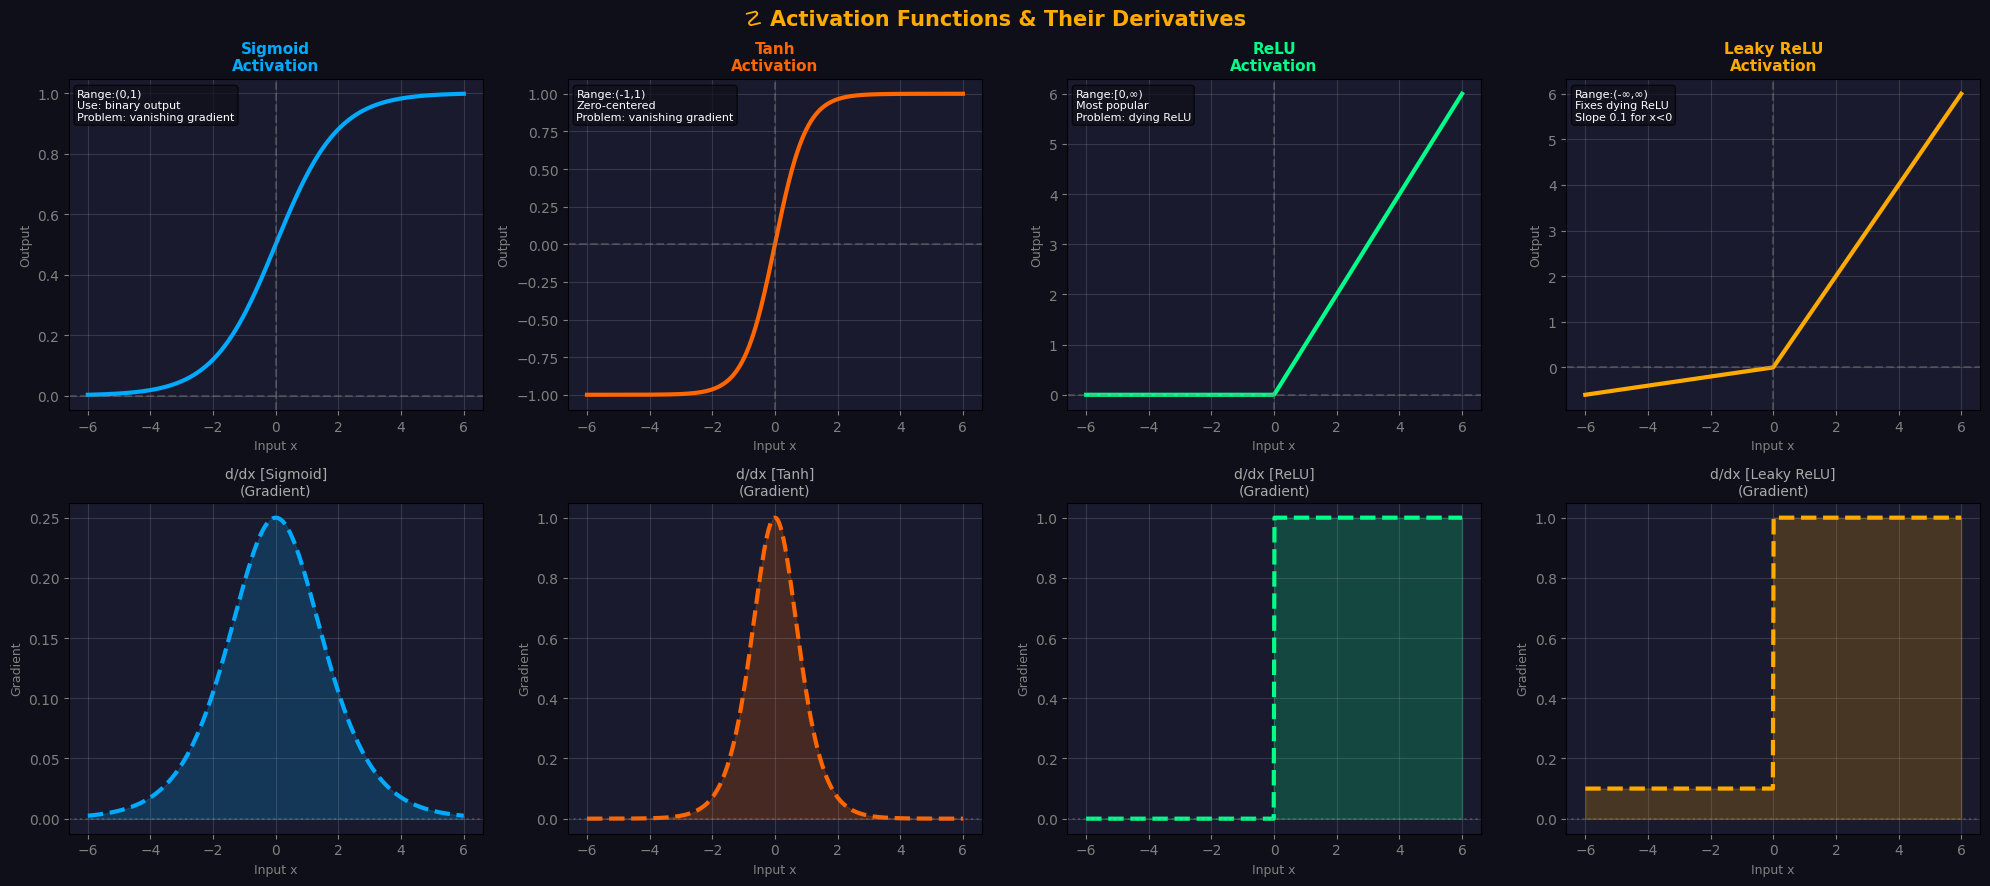


⌖ SOFTMAX — Converting Raw Scores to Probabilities
Class         Score    Softmax  Bar
--------------------------------------------------
Cat            2.00     0.1653  ██████
Dog            1.00     0.0608  ██
Bird           0.10     0.0247  
Fish          -1.00     0.0082  
Rabbit         3.50     0.7409  █████████████████████████████

Sum = 1.000000  (always 1.0 ✅)
Prediction: Rabbit (74.09% confidence)


In [ ]:
# ============================================================
# SECTION 10: ACTIVATION FUNCTIONS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 500)

def sigmoid(x):   return 1/(1+np.exp(-np.clip(x,-500,500)))
def tanh(x):      return np.tanh(x)
def relu(x):      return np.maximum(0, x)
def leaky(x):     return np.where(x>0, x, 0.1*x)
def d_sigmoid(x): s=sigmoid(x); return s*(1-s)
def d_tanh(x):    return 1-np.tanh(x)**2
def d_relu(x):    return (x>0).astype(float)
def d_leaky(x):   return np.where(x>0, 1.0, 0.1)

act_info = [
  ('Sigmoid',     sigmoid, d_sigmoid, '#00aaff',
   'Range:(0,1)\nUse: binary output\nProblem: vanishing gradient'),
  ('Tanh',        tanh,    d_tanh,    '#ff6600',
   'Range:(-1,1)\nZero-centered\nProblem: vanishing gradient'),
  ('ReLU',        relu,    d_relu,    '#00ff88',
   'Range:[0,∞)\nMost popular\nProblem: dying ReLU'),
  ('Leaky ReLU',  leaky,   d_leaky,   '#ffaa00',
   'Range:(-∞,∞)\nFixes dying ReLU\nSlope 0.1 for x<0'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0f0f1a')

for col,(name,fn,dfn,color,desc) in enumerate(act_info):
  # Top: function
  ax = axes[0,col]
  ax.set_facecolor('#1a1a2e')
  ax.plot(x, fn(x), color=color, linewidth=3)
  ax.axhline(0,color='gray',linestyle='--',alpha=0.4)
  ax.axvline(0,color='gray',linestyle='--',alpha=0.4)
  ax.set_title(f'{name}\nActivation', color=color, fontsize=11, fontweight='bold')
  ax.set_xlabel('Input x', color='gray', fontsize=9)
  ax.set_ylabel('Output', color='gray', fontsize=9)
  ax.tick_params(colors='gray')
  ax.grid(True, alpha=0.2)
  ax.text(0.02,0.97,desc,transform=ax.transAxes,fontsize=8,va='top',color='white',
          bbox=dict(boxstyle='round',facecolor='#0f0f1a',alpha=0.7))

  # Bottom: derivative
  ax2 = axes[1,col]
  ax2.set_facecolor('#1a1a2e')
  dv = np.clip(dfn(x), -3, 3)
  ax2.plot(x, dv, color=color, linewidth=3, linestyle='--')
  ax2.fill_between(x, 0, dv, alpha=0.2, color=color)
  ax2.axhline(0,color='gray',linestyle=':',alpha=0.4)
  ax2.set_title(f"d/dx [{name}]\n(Gradient)", color='#aaa', fontsize=10)
  ax2.set_xlabel('Input x', color='gray', fontsize=9)
  ax2.set_ylabel('Gradient', color='gray', fontsize=9)
  ax2.tick_params(colors='gray')
  ax2.grid(True, alpha=0.2)

plt.suptitle('☡ Activation Functions & Their Derivatives',
           fontsize=15, color='#ffaa00', fontweight='bold')
plt.tight_layout()
plt.show()

# Softmax demo
print("\n⌖ SOFTMAX — Converting Raw Scores to Probabilities")
print("="*55)
scores = np.array([2.0, 1.0, 0.1, -1.0, 3.5])
classes = ['Cat','Dog','Bird','Fish','Rabbit']
exp_s = np.exp(scores - scores.max())
softmax = exp_s / exp_s.sum()
print(f"{'Class':<10} {'Score':>8} {'Softmax':>10}  Bar")
print("-"*50)
for cls,sc,sm in zip(classes,scores,softmax):
  bar='█'*int(sm*40)
  print(f"{cls:<10} {sc:>8.2f} {sm:>10.4f}  {bar}")
print(f"\nSum = {softmax.sum():.6f}  (always 1.0 ✅)")
print(f"Prediction: {classes[np.argmax(softmax)]} ({softmax.max():.2%} confidence)")

---
    # 🔷 SECTION 11: Pooling | SECTION 12: Flatten | SECTION 13: Dense | SECTION 14: Forward Propagation

    ---

    ## SECTION 11: Pooling Layer

    **Max Pooling** takes the maximum value from each pool region:

    ```
    Input (4×4):              Output (2×2, pool=2×2, stride=2):
    ┌──┬──┬──┬──┐             ┌──┬──┐
    │1 │3 │2 │4 │             │6 │8 │   max(1,3,5,6)=6  max(2,4,7,8)=8
    ├──┼──┼──┼──┤     →       ├──┼──┤
    │5 │6 │7 │8 │             │9 │5 │   max(3,2,9,4)=9  max(1,0,3,5)=5
    ├──┼──┼──┼──┤             └──┴──┘
    │3 │2 │1 │0 │
    ├──┼──┼──┼──┤
    │9 │4 │3 │5 │
    └──┴──┴──┴──┘
    ```

    ---

    ## SECTION 12: Flatten Layer

    Converts 3D tensor → 1D vector for Dense layers:
    ```
    Before: (8, 8, 64)  =  4,096 values in 3D grid
    After:  (4096,)     =  4,096 values in 1D vector
    ```

    ---

    ## SECTION 13: Dense (Fully Connected) Layer

    Every neuron receives input from ALL previous neurons:
    $$y_k = \text{activation}\left(\sum_i w_{ki} x_i + b_k\right)$$

    ---

    ## SECTION 14: Forward Propagation (Step-by-Step)

    ```
    Input:  x = [0.5, 0.2, 0.8, 0.1]
    Weights: W₁ = [[0.3, -0.1, 0.5, 0.2], [0.1, 0.4, -0.3, 0.6]]
    Biases:  b₁ = [0.1, -0.2]

    Step 1: z₁ = W₁·x + b₁ = [0.65, -0.25]
    Step 2: a₁ = ReLU(z₁)  = [0.65, 0.00]
    Step 3: z₂ = W₂·a₁ + b₂ = [0.51]
    Step 4: ŷ  = Sigmoid(z₂) = 0.625 → Dog (62.5% confidence)
    ```
    

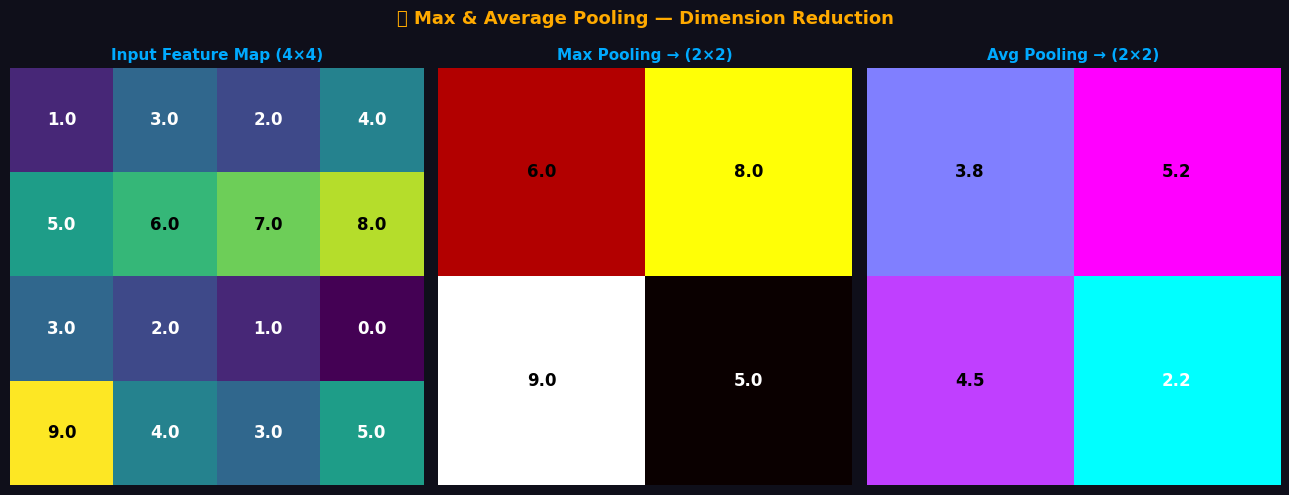

Input:     (4, 4) = 16 values
After pool:(2, 2)  = 4 values  (4× smaller)

SECTION 14: FORWARD PROPAGATION DEMO
Input x = [0.5 0.2 0.8 0.1]

Layer 1: z1 = W1·x + b1 = [ 0.65 -0.25]
ReLU(z1)= a1 = [0.65 0.  ]

Layer 2: z2 = W2·a1 + b2 = [0.505]
Sigmoid(z2)= ŷ = 0.6236

🎯 Prediction: 62.4% → Dog 🐶


In [ ]:
# ============================================================
# SECTIONS 11-14: POOLING, FLATTEN, DENSE, FORWARD PROP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── POOLING ──────────────────────────────────────────────
def max_pool(fm, p=2, s=2):
  H,W=fm.shape; oH=(H-p)//s+1; oW=(W-p)//s+1
  out=np.zeros((oH,oW))
  for i in range(oH):
      for j in range(oW):
          out[i,j]=np.max(fm[i*s:i*s+p, j*s:j*s+p])
  return out

def avg_pool(fm, p=2, s=2):
  H,W=fm.shape; oH=(H-p)//s+1; oW=(W-p)//s+1
  out=np.zeros((oH,oW))
  for i in range(oH):
      for j in range(oW):
          out[i,j]=np.mean(fm[i*s:i*s+p, j*s:j*s+p])
  return out

fm4 = np.array([[1,3,2,4],[5,6,7,8],[3,2,1,0],[9,4,3,5]], dtype=float)
mp = max_pool(fm4)
ap = avg_pool(fm4)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, data, title, cmap in [
  (axes[0], fm4, 'Input Feature Map (4×4)', 'viridis'),
  (axes[1], mp,  'Max Pooling → (2×2)', 'hot'),
  (axes[2], ap,  'Avg Pooling → (2×2)', 'cool'),
]:
  ax.set_facecolor('#1a1a2e')
  ax.imshow(data, cmap=cmap, aspect='auto')
  ax.set_title(title, color='#00aaff', fontsize=11, fontweight='bold')
  for r in range(data.shape[0]):
      for c in range(data.shape[1]):
          v=data[r,c]
          ax.text(c,r,f'{v:.1f}',ha='center',va='center',fontsize=12,fontweight='bold',
                  color='black' if v>data.max()*.6 else 'white')
  ax.axis('off')

plt.suptitle('🎯 Max & Average Pooling — Dimension Reduction',
           fontsize=13, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Input:     {fm4.shape} = {fm4.size} values")
print(f"After pool:{mp.shape}  = {mp.size} values  ({fm4.size//mp.size}× smaller)")

# ── FORWARD PROPAGATION ──────────────────────────────────
print("\n" + "="*55)
print("SECTION 14: FORWARD PROPAGATION DEMO")
print("="*55)

x = np.array([0.5, 0.2, 0.8, 0.1])
W1 = np.array([[0.3,-0.1,0.5,0.2],[0.1,0.4,-0.3,0.6]])
b1 = np.array([0.1,-0.2])
W2 = np.array([[0.7,-0.4]])
b2 = np.array([0.05])

relu  = lambda z: np.maximum(0, z)
sigm  = lambda z: 1/(1+np.exp(-z))

print(f"Input x = {x}")
z1 = W1@x + b1
print(f"\nLayer 1: z1 = W1·x + b1 = {np.round(z1,4)}")
a1 = relu(z1)
print(f"ReLU(z1)= a1 = {np.round(a1,4)}")
z2 = W2@a1 + b2
print(f"\nLayer 2: z2 = W2·a1 + b2 = {np.round(z2,4)}")
yhat = sigm(z2)
print(f"Sigmoid(z2)= ŷ = {yhat[0]:.4f}")
print(f"\n🎯 Prediction: {yhat[0]*100:.1f}% → {'Dog 🐶' if yhat[0]>=0.5 else 'Cat 🐱'}")

---
    # 🔷 SECTION 15: Loss Function | SECTION 16: Backpropagation | SECTION 17: Optimizers

    ---

    ## SECTION 15: Binary Cross-Entropy Loss

    $$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

    **Example:**
    ```
    True label: y = 1 (Dog)

    Good prediction  ŷ = 0.90 → L = -log(0.90) = 0.105  ← small loss ✅
    Bad prediction   ŷ = 0.10 → L = -log(0.10) = 2.303  ← large loss ❌
    ```

    ---

    ## SECTION 16: Backpropagation

    ```
    Forward:  Input → Prediction → Loss
    Backward: Loss → ∂L/∂W → Update W
    ```

    **Weight update rule (Gradient Descent):**
    $$W \leftarrow W - \alpha \cdot \frac{\partial \mathcal{L}}{\partial W}$$

    **Chain rule** propagates gradients backward:
    $$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial W_1}$$

    ---

    ## SECTION 17: Optimizers

    | Optimizer | Rule | When to Use |
    |-----------|------|------------|
    | **SGD** | $W = W - \alpha g$ | Simple, needs tuning |
    | **Adam** | Adaptive per-param LR | **Best default ✅** |
    | **RMSProp** | Adaptive + running mean | RNNs, LSTMs |

    **Adam default hyperparams:** $\alpha=0.001$, $\beta_1=0.9$, $\beta_2=0.999$
    

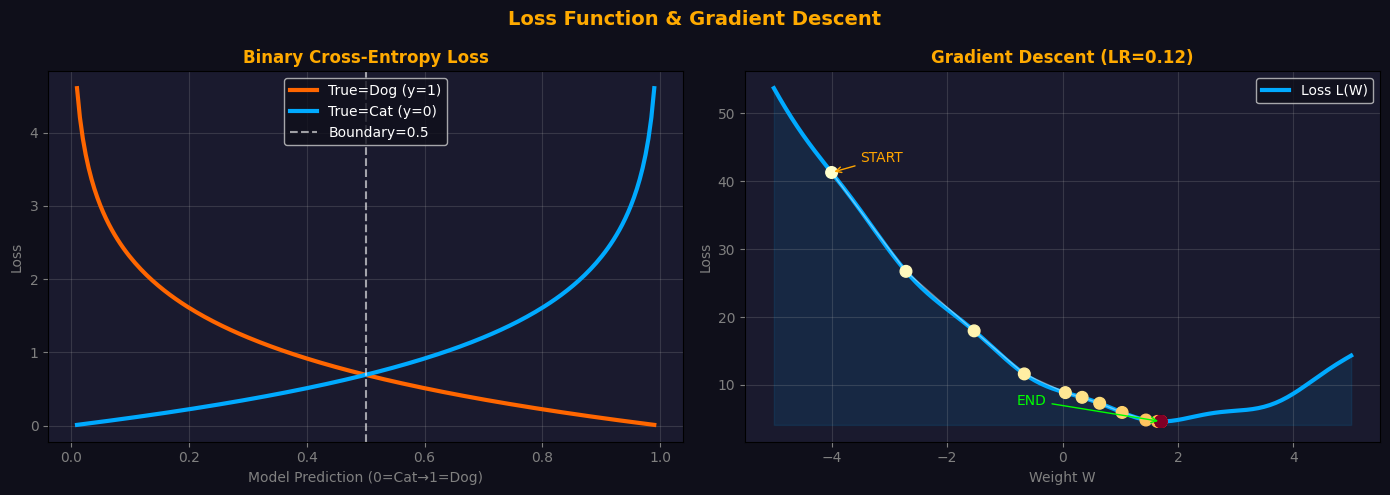

Start: W=-4.00, Loss=41.268
End:   W=1.71, Loss=4.627

🔑 Optimizer automates this update for millions of weights during training!


In [ ]:
# ============================================================
# SECTIONS 15-17: LOSS, BACKPROP, GRADIENT DESCENT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── BINARY CROSS-ENTROPY ─────────────────────────────────
def bce(y_true, y_pred):
  eps = 1e-15
  y_pred = np.clip(y_pred, eps, 1-eps)
  return -(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

y_pred_range = np.linspace(0.01, 0.99, 200)
loss_dog = [bce(1, p) for p in y_pred_range]
loss_cat = [bce(0, p) for p in y_pred_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.plot(y_pred_range, loss_dog, '#ff6600', linewidth=3, label='True=Dog (y=1)')
ax.plot(y_pred_range, loss_cat, '#00aaff', linewidth=3, label='True=Cat (y=0)')
ax.axvline(0.5,color='white',linestyle='--',alpha=0.6,label='Boundary=0.5')
ax.set_title('Binary Cross-Entropy Loss', color='#ffaa00', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Prediction (0=Cat→1=Dog)', color='gray')
ax.set_ylabel('Loss', color='gray')
ax.tick_params(colors='gray')
ax.legend(fontsize=10, labelcolor='white', facecolor='#0f0f1a')
ax.grid(True, alpha=0.2)

# ── GRADIENT DESCENT ─────────────────────────────────────
w = np.linspace(-5, 5, 200)
loss_landscape = (w-2)**2 + 0.5*np.sin(3*w) + 5

wt = -4.0; lr = 0.12; traj = [wt]
for _ in range(25):
  grad = 2*(wt-2) + 1.5*np.cos(3*wt)
  wt = wt - lr*grad
  traj.append(wt)

traj_loss = [(wv-2)**2+0.5*np.sin(3*wv)+5 for wv in traj]

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.plot(w, loss_landscape, '#00aaff', linewidth=3, label='Loss L(W)')
ax2.fill_between(w, loss_landscape, min(loss_landscape)-0.5, alpha=0.1, color='#00aaff')
sc = ax2.scatter(traj, traj_loss, c=range(len(traj)), cmap='YlOrRd', s=70, zorder=3)
ax2.plot(traj, traj_loss, 'white', linewidth=1, alpha=0.4, zorder=2)
ax2.annotate('START', xy=(traj[0],traj_loss[0]), xytext=(traj[0]+0.5,traj_loss[0]+1.5),
           arrowprops=dict(arrowstyle='->',color='orange'), color='orange', fontsize=10)
ax2.annotate('END', xy=(traj[-1],traj_loss[-1]), xytext=(traj[-1]-2.5,traj_loss[-1]+2.5),
           arrowprops=dict(arrowstyle='->',color='lime'), color='lime', fontsize=10)
ax2.set_title(f'Gradient Descent (LR={lr})', color='#ffaa00', fontsize=12, fontweight='bold')
ax2.set_xlabel('Weight W', color='gray')
ax2.set_ylabel('Loss', color='gray')
ax2.tick_params(colors='gray')
ax2.legend(fontsize=10, labelcolor='white', facecolor='#0f0f1a')
ax2.grid(True, alpha=0.2)

plt.suptitle('Loss Function & Gradient Descent',
           fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Start: W={traj[0]:.2f}, Loss={traj_loss[0]:.3f}")
print(f"End:   W={traj[-1]:.2f}, Loss={traj_loss[-1]:.3f}")
print(f"\n🔑 Optimizer automates this update for millions of weights during training!")

---
    # 🔷 SECTION 18: CNN Model 1 — Simple CNN

    ---

    ## Architecture Design

    ```
    Input  (128×128×3)
    ↓  Conv2D(32, 3×3, ReLU, same)
    ↓  MaxPool(2×2)
    ↓  Conv2D(64, 3×3, ReLU, same)
    ↓  MaxPool(2×2)
    ↓  Conv2D(64, 3×3, ReLU, same)
    ↓  MaxPool(2×2)
    ↓  Flatten
    ↓  Dense(128, ReLU)
    ↓  Dense(1, Sigmoid)  → probability 0.0–1.0
    ```

    ## Compile Settings
    - **Optimizer:** Adam (lr=0.001)
    - **Loss:** binary_crossentropy
    - **Metric:** accuracy
    

In [ ]:
# ============================================================
# SECTION 18: BUILD CNN MODEL 1 (SIMPLE CNN)
# ============================================================

from tensorflow.keras import layers, models, optimizers
import tensorflow as tf

def build_model1(input_shape=(128,128,3)):
  """
  Simple CNN for binary classification (Cat=0, Dog=1).
  Architecture: 3×(Conv→Pool) → Flatten → Dense(128) → Output
  """
  model = models.Sequential([
      layers.Input(shape=input_shape),

      # Block 1: detect basic edges & colors
      layers.Conv2D(32, (3,3), activation='relu', padding='same', name='b1_conv'),
      layers.MaxPooling2D((2,2), name='b1_pool'),

      # Block 2: detect shapes & textures
      layers.Conv2D(64, (3,3), activation='relu', padding='same', name='b2_conv'),
      layers.MaxPooling2D((2,2), name='b2_pool'),

      # Block 3: detect complex features (eyes, ears)
      layers.Conv2D(64, (3,3), activation='relu', padding='same', name='b3_conv'),
      layers.MaxPooling2D((2,2), name='b3_pool'),

      # Classifier head
      layers.Flatten(name='flatten'),
      layers.Dense(128, activation='relu', name='dense1'),
      layers.Dense(1, activation='sigmoid', name='output'),  # 0=Cat 1=Dog
  ], name='CNN_Model_1')
  return model

model1 = build_model1(input_shape=(IMG_SIZE, IMG_SIZE, 3))

model1.compile(
  optimizer=optimizers.Adam(learning_rate=0.001),
  loss='binary_crossentropy',
  metrics=['accuracy']
)

print("📋 CNN MODEL 1 ARCHITECTURE:")
model1.summary()
total = model1.count_params()
print(f"\n📊 Total parameters: {total:,}")
print(f"   Memory: {total*4/1024:.1f} KB (float32)")

📋 CNN MODEL 1 ARCHITECTURE:


Model: "CNN_Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ b1_conv (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,153,729 (8.22 MB)

 Trainable params: 2,153,729 (8.22 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total parameters: 2,153,729
   Memory: 8413.0 KB (float32)


| Layer               | Output Shape | Trainable Parameters | What It Learns                                     |
| ------------------- | ------------ | -------------------: | -------------------------------------------------- |
| Input               | 128×128×3    |                    0 | Raw RGB image                                      |
| Conv2D (32 filters) | 128×128×32   |              **896** | Edges, colors                                      |
| MaxPool             | 64×64×32     |                    0 | Downsampling                                       |
| Conv2D (64 filters) | 64×64×64     |           **18,496** | Shapes, textures                                   |
| MaxPool             | 32×32×64     |                    0 | Downsampling                                       |
| Conv2D (64 filters) | 32×32×64     |           **36,928** | Eyes, ears, facial parts                           |
| MaxPool             | 16×16×64     |                    0 | Downsampling                                       |
| Flatten             | 16,384       |                    0 | Convert feature maps into a vector                 |
| Dense (128)         | 128          |        **2,097,280** | Combines all extracted features for classification |
| Dense (1)           | 1            |              **129** | Produces Cat/Dog probability                       |


---
    # 🔷 SECTION 19: Training the Model

    ---

    ## Training Loop (per epoch):
    ```
    For each batch of 32 images:
    1. Forward pass  → predictions
    2. Compute loss  → how wrong are we?
    3. Backward pass → compute gradients
    4. Update weights → optimizer step

    After all batches → 1 epoch complete:
    → Print train accuracy & loss
    → Evaluate on validation set
    ```

    ## Callbacks Used:
    - **EarlyStopping:** stops if val_loss doesn't improve for 5 epochs
    - **ReduceLROnPlateau:** halves learning rate after 3 stagnant epochs
    

In [ ]:
# ============================================================
# SECTION 19: TRAIN MODEL 1
# ============================================================

import time
import tensorflow as tf

callbacks = [
  tf.keras.callbacks.EarlyStopping(
      monitor='val_loss', patience=5,
      restore_best_weights=True, verbose=1
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
      monitor='val_loss', factor=0.5,
      patience=3, min_lr=1e-7, verbose=1
  )
]

print("🚀 Training CNN Model 1...")
print("="*55)
print(f"Train samples  : {len(X_train_f)}")
print(f"Val samples    : {len(X_val)}")
print(f"Batch size     : 32")
print(f"Max epochs     : 20")
print("="*55)

t0 = time.time()

history1 = model1.fit(
  X_train_f, y_train_f,
  epochs=20,
  batch_size=32,
  validation_data=(X_val, y_val),
  callbacks=callbacks,
  verbose=1
)

time1 = time.time() - t0
ep1 = len(history1.history['loss'])

print(f"\n✅ Training complete!")
print(f"   Epochs trained     : {ep1}")
print(f"   Training time      : {time1:.1f}s")
print(f"   Final train acc    : {history1.history['accuracy'][-1]*100:.2f}%")
print(f"   Final val acc      : {history1.history['val_accuracy'][-1]*100:.2f}%")

🚀 Training CNN Model 1...
Train samples  : 2557
Val samples    : 640
Batch size     : 32
Max epochs     : 20
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8017 - loss: 0.4332 - val_accuracy: 0.7125 - val_loss: 0.6217 - learning_rate: 5.0000e-04
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8213 - loss: 0.3986 - val_accuracy: 0.7125 - val_loss: 0.6068 - learning_rate: 5.0000e-04
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8299 - loss: 0.3767 - val_accuracy: 0.7000 - val_loss: 0.6455 - learning_rate: 5.0000e-04
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8487 - loss: 0.3408 - val_accuracy: 0.7141 - val_loss: 0.6412 - learning_rate: 5.0000e-04
Epoch 5/20
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8795 - loss: 0.3009
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8776 - loss: 0.3041 - val_accuracy: 0.7188 - val_loss: 0

---
    # 🔷 SECTION 20: Training Graphs

    ---

    ## How to Read the Curves

    | Pattern | Accuracy Graph | Loss Graph | Meaning |
    |---------|---------------|-----------|---------|
    | Both rising | ✅ Up | ✅ Down | Still learning |
    | Gap increasing | Train>>Val | Train<<Val | Overfitting! |
    | Both plateau | Flat | Flat | Converged |
    | Val > Train | Unusual | Unusual | Good regularization |
    

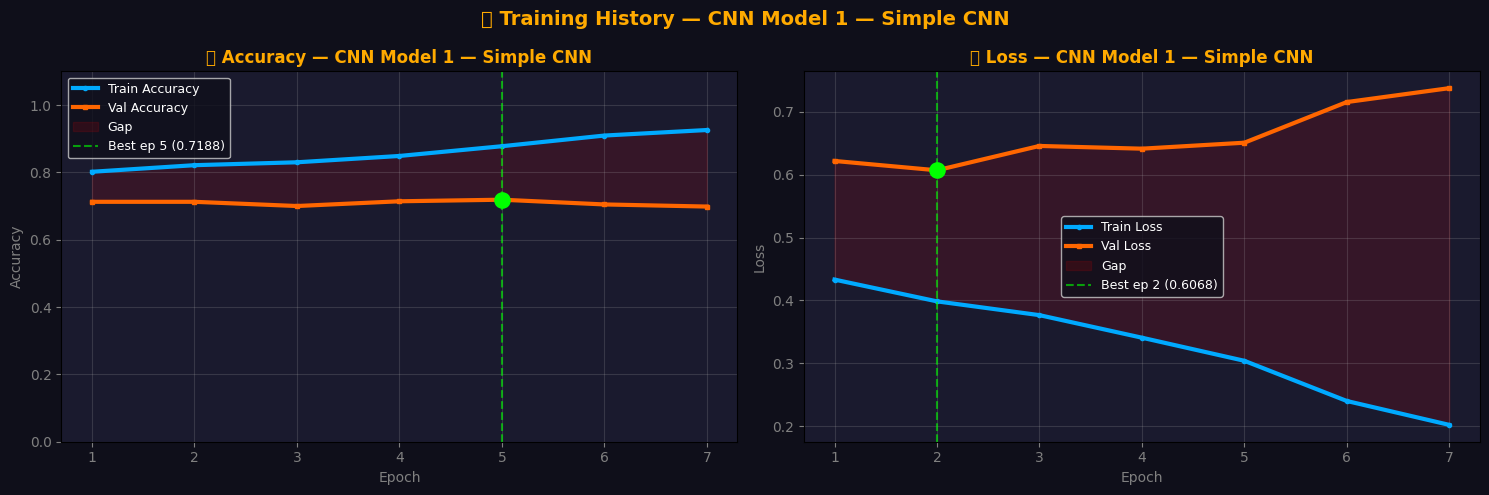


📊 CNN Model 1 — Simple CNN Analysis:
  Best val accuracy : 71.88%
  Train/Val gap     : 22.73%  ❌ Overfitting — add Dropout or more data


In [ ]:
# ============================================================
# SECTION 20: TRAINING CURVES
# ============================================================

def plot_history(history, name="Model"):
  ep = range(1, len(history.history['accuracy'])+1)
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))
  fig.patch.set_facecolor('#0f0f1a')

  for ax, metric, ylabel, title in [
      (axes[0], 'accuracy',    'Accuracy', f'📈 Accuracy — {name}'),
      (axes[1], 'loss',        'Loss',     f'📉 Loss — {name}'),
  ]:
      ax.set_facecolor('#1a1a2e')
      tr = history.history[metric]
      va = history.history[f'val_{metric}']

      ax.plot(ep, tr, '#00aaff', linewidth=3, marker='o', markersize=3, label=f'Train {ylabel}')
      ax.plot(ep, va, '#ff6600', linewidth=3, marker='s', markersize=3, label=f'Val {ylabel}')
      ax.fill_between(ep, tr, va, alpha=0.12, color='red', label='Gap')

      best = (np.argmax if metric=='accuracy' else np.argmin)(va)
      bv   = (max if metric=='accuracy' else min)(va)
      ax.scatter([ep[best]], [bv], s=120, color='lime', zorder=5)
      ax.axvline(ep[best], color='lime', linestyle='--', alpha=0.6,
                 label=f'Best ep {ep[best]} ({bv:.4f})')

      ax.set_title(title, color='#ffaa00', fontsize=12, fontweight='bold')
      ax.set_xlabel('Epoch', color='gray'); ax.set_ylabel(ylabel, color='gray')
      ax.tick_params(colors='gray')
      ax.legend(fontsize=9, labelcolor='white', facecolor='#0f0f1a')
      ax.grid(True, alpha=0.2)
      if metric=='accuracy': ax.set_ylim(0,1.1)

  plt.suptitle(f'🎓 Training History — {name}', fontsize=14, color='#ffaa00', fontweight='bold')
  plt.tight_layout(); plt.show()

  ta = history.history['accuracy'][-1]
  va2 = history.history['val_accuracy'][-1]
  gap = ta - va2
  print(f"\n📊 {name} Analysis:")
  print(f"  Best val accuracy : {max(history.history['val_accuracy'])*100:.2f}%")
  print(f"  Train/Val gap     : {gap*100:.2f}%", end="  ")
  if gap<0.05: print("✅ Good fit")
  elif gap<0.12: print("⚠️  Slight overfitting")
  else: print("❌ Overfitting — add Dropout or more data")

plot_history(history1, "CNN Model 1 — Simple CNN")

---
    # 🔷 SECTION 21: Making Predictions

    ---

    ## Prediction Pipeline

    ```
    New Image (any size)
      ↓ cv2.resize(128×128)
      ↓ img / 255.0
      ↓ np.expand_dims → (1,128,128,3)
      ↓ model.predict()
      ↓ probability (0.0–1.0)
      ↓
    < 0.5 → Cat (confidence = 1-p)
    ≥ 0.5 → Dog (confidence = p)
    ```
    

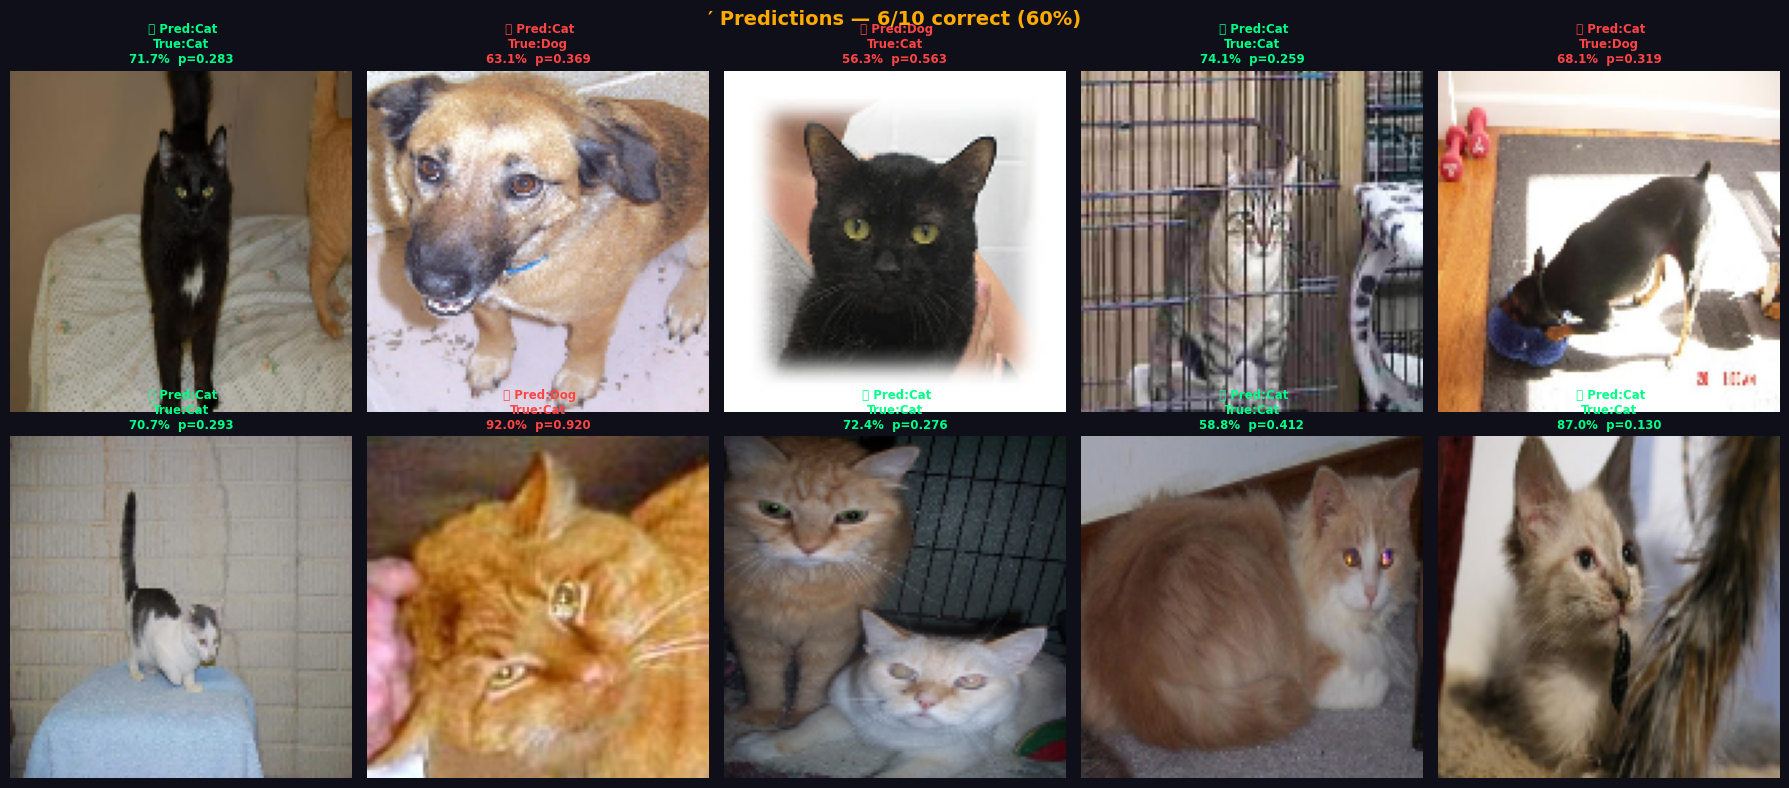

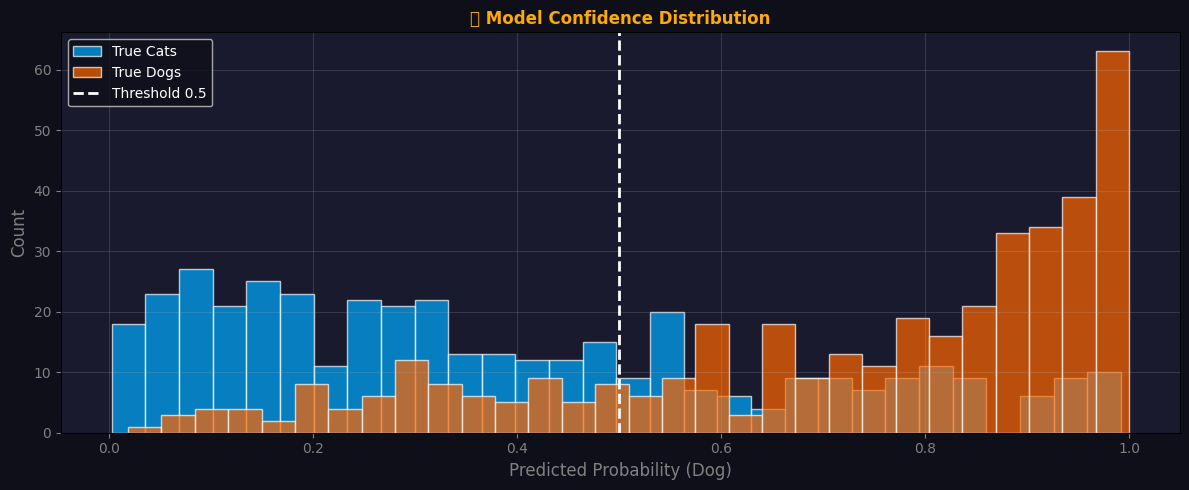

In [ ]:
# ============================================================
# SECTION 21: PREDICTIONS
# ============================================================

def predict_image(model, img_array, threshold=0.5):
  """
  Predict class of a single normalized image array.
  Returns (class_name, confidence%, raw_prob)
  """
  batch = np.expand_dims(img_array, axis=0)  # (H,W,3) → (1,H,W,3)
  prob  = model.predict(batch, verbose=0)[0][0]  # raw sigmoid output
  if prob >= threshold:
      return 'Dog', prob*100, prob
  else:
      return 'Cat', (1-prob)*100, prob

# Predict on test samples
n = min(10, len(X_test))
idxs = np.random.choice(len(X_test), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.patch.set_facecolor('#0f0f1a')
axes = axes.flatten()

correct = 0
for ax, idx in zip(axes, idxs):
  img  = X_test[idx]
  true = CATEGORIES[int(y_test[idx])]
  pred, conf, raw = predict_image(model1, img)
  ok = (pred == true); correct += ok

  ax.imshow(img)
  color = '#00ff88' if ok else '#ff4444'
  ax.set_title(f"{' ✅' if ok else ' ❌'} Pred:{pred}\nTrue:{true}\n{conf:.1f}%  p={raw:.3f}",
               color=color, fontsize=8.5, fontweight='bold')
  for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(3)
  ax.axis('off')

plt.suptitle(f'′ Predictions — {correct}/{n} correct ({correct/n*100:.0f}%)',
           fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

# Confidence distribution
probs = model1.predict(X_test, verbose=0).flatten()
fig, ax = plt.subplots(figsize=(12,5))
fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#1a1a2e')
ax.hist(probs[y_test==0], bins=30, alpha=0.7, color='#00aaff', edgecolor='white', label='True Cats')
ax.hist(probs[y_test==1], bins=30, alpha=0.7, color='#ff6600', edgecolor='white', label='True Dogs')
ax.axvline(0.5, color='white', linewidth=2, linestyle='--', label='Threshold 0.5')
ax.set_xlabel('Predicted Probability (Dog)', color='gray', fontsize=12)
ax.set_ylabel('Count', color='gray', fontsize=12)
ax.set_title('့ Model Confidence Distribution', color='#ffaa00', fontsize=12, fontweight='bold')
ax.tick_params(colors='gray')
ax.legend(fontsize=10, labelcolor='white', facecolor='#0f0f1a')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

---
    # 🔷 SECTION 22: Confusion Matrix & Evaluation Metrics

    ---

    ## Confusion Matrix Layout

    ```
                      PREDICTED
                    Cat     Dog
    ACTUAL   Cat  [ TN=✅  | FP=❌ ]
           Dog  [ FN=❌  | TP=✅ ]
    ```

    ## Key Metrics

    $$\text{Accuracy}  = \frac{TP+TN}{TP+TN+FP+FN}$$
    $$\text{Precision} = \frac{TP}{TP+FP}$$
    $$\text{Recall}    = \frac{TP}{TP+FN}$$
    $$\text{F1 Score}  = \frac{2 \times P \times R}{P+R}$$
    

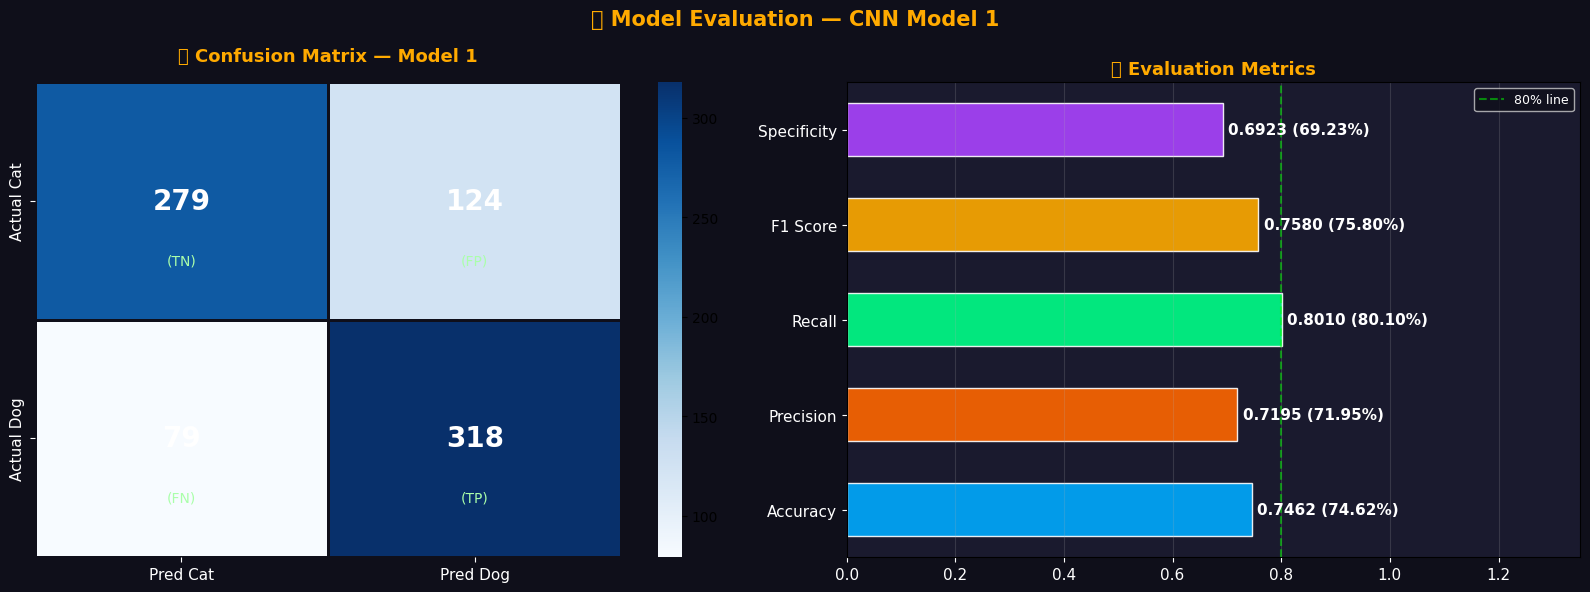


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Cat     0.7793    0.6923    0.7332       403
         Dog     0.7195    0.8010    0.7580       397

    accuracy                         0.7462       800
   macro avg     0.7494    0.7467    0.7456       800
weighted avg     0.7496    0.7462    0.7456       800

  TN=279 (cats correctly found)  FP=124 (cats called dogs)
  FN=79 (dogs called cats)      TP=318 (dogs correctly found)


In [ ]:
# ============================================================
# SECTION 22: CONFUSION MATRIX & METRICS
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

y_pred1 = (model1.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
acc1     = accuracy_score(y_test.astype(int), y_pred1)
cm1      = confusion_matrix(y_test.astype(int), y_pred1)
tn,fp,fn,tp = cm1.ravel()

precision1  = tp/(tp+fp) if (tp+fp)>0 else 0
recall1     = tp/(tp+fn) if (tp+fn)>0 else 0
f1_1        = 2*precision1*recall1/(precision1+recall1) if (precision1+recall1)>0 else 0
spec1       = tn/(tn+fp) if (tn+fp)>0 else 0

fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.patch.set_facecolor('#0f0f1a')

# Confusion matrix heatmap
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
          xticklabels=['Pred Cat','Pred Dog'],
          yticklabels=['Actual Cat','Actual Dog'],
          linewidths=2, linecolor='#0f0f1a',
          annot_kws={'size':20,'weight':'bold','color':'white'})
axes[0].set_title('🎯 Confusion Matrix — Model 1',
                color='#ffaa00', fontsize=13, fontweight='bold', pad=15)
axes[0].tick_params(colors='white', labelsize=11)
for (i,j),lbl in [((0,0),'TN'),((0,1),'FP'),((1,0),'FN'),((1,1),'TP')]:
  axes[0].text(j+0.5,i+0.75,f'({lbl})',ha='center',va='center',
              fontsize=10,color='#aaffaa')

# Metrics bar chart
ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
metrics = {'Accuracy':acc1,'Precision':precision1,'Recall':recall1,'F1 Score':f1_1,'Specificity':spec1}
cols_m = ['#00aaff','#ff6600','#00ff88','#ffaa00','#aa44ff']
bars = ax2.barh(list(metrics.keys()), list(metrics.values()),
             color=cols_m, edgecolor='white', height=0.55, alpha=0.9)
for bar,(name,val) in zip(bars,metrics.items()):
  ax2.text(val+0.01, bar.get_y()+bar.get_height()/2,
           f'{val:.4f} ({val*100:.2f}%)', va='center', color='white',
           fontsize=11, fontweight='bold')
ax2.set_xlim(0,1.35)
ax2.set_title('📊 Evaluation Metrics',
            color='#ffaa00', fontsize=13, fontweight='bold')
ax2.tick_params(colors='white', labelsize=11)
ax2.axvline(0.8, color='lime', linestyle='--', alpha=0.5, label='80% line')
ax2.legend(fontsize=9, labelcolor='white', facecolor='#0f0f1a')
ax2.grid(True, alpha=0.2, axis='x')

plt.suptitle('🔍 Model Evaluation — CNN Model 1',
           fontsize=15, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📋 CLASSIFICATION REPORT:")
print("="*55)
print(classification_report(y_test.astype(int), y_pred1,
                          target_names=['Cat','Dog'], digits=4))
print(f"  TN={tn} (cats correctly found)  FP={fp} (cats called dogs)")
print(f"  FN={fn} (dogs called cats)      TP={tp} (dogs correctly found)")

---
    # 🔷 SECTION 23: CNN Model 2 — Deeper CNN with Dropout

    ---

    ## Improvements Over Model 1

    | Feature | Model 1 | Model 2 |
    |---------|---------|---------|
    | Conv filters | 32 → 64 → 64 | 64 → 128 → 256 |
    | Batch Normalization | ❌ | ✅ |
    | Dropout | ❌ | ✅ (0.25, 0.5) |
    | Dense size | 128 | 256 + 128 |

    ## Architecture:
    ```
    Input → [Conv64+BN+ReLU+Pool+Dropout(0.25)] ×2
        → [Conv256+BN+ReLU+Pool+Dropout(0.25)]
        → Flatten → Dense256+BN+ReLU+Dropout(0.5)
        → Dense128+ReLU+Dropout(0.3)
        → Output(1, Sigmoid)
    ```
    

  CLASSIFICATION REPORT:


Model: "CNN_Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ b1c1 (Conv2D)                   │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1bn (BatchNormalization)       │ (None, 128, 128, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1c2 (Conv2D)                   │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2c1 (Conv2D)                   │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2c2 (Conv2D)                   │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3c1 (Conv2D)                   │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,47

 Total params: 17,369,409 (66.26 MB)

 Trainable params: 17,367,617 (66.25 MB)

 Non-trainable params: 1,792 (7.00 KB)


Model 1 params: 2,153,729
Model 2 params: 17,369,409

✅ Training Model 2...
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 52s 347ms/step - accuracy: 0.5702 - loss: 0.7429 - val_accuracy: 0.5047 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.6343 - loss: 0.6553 - val_accuracy: 0.5234 - val_loss: 0.7250 - learning_rate: 0.0010
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6855 - loss: 0.5875
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.6977 - loss: 0.5690 - val_accuracy: 0.5500 - val_loss: 0.7855 - learning_rate: 0.0010
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.7364 - loss: 0.5352 - val_accuracy: 0.5063 - val_loss: 0.8043 - learning_rate: 5.0000e-04
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.7622 - loss: 0.4913 - val_accuracy: 0.5172 - val_loss: 0.9390 - learning_rate: 5.0000e-04
Epoch 

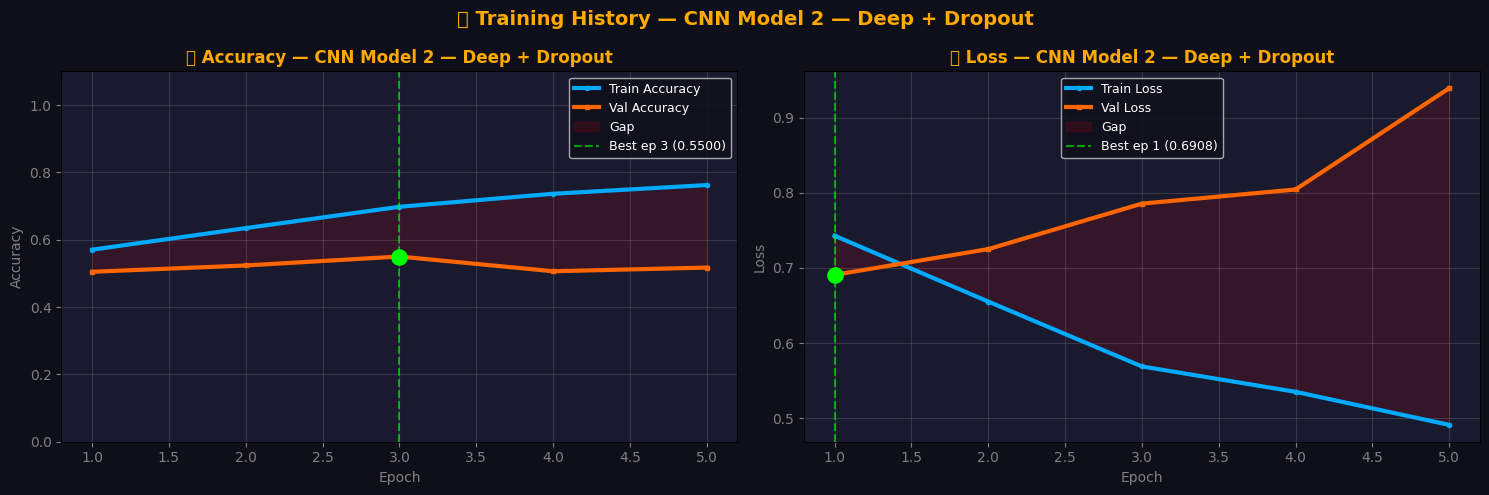


📊 CNN Model 2 — Deep + Dropout Analysis:
  Best val accuracy : 55.00%
  Train/Val gap     : 24.50%  ❌ Overfitting — add Dropout or more data


In [ ]:
# ============================================================
# SECTION 23: CNN MODEL 2 (DEEPER + DROPOUT + BATCHNORM)
# ============================================================

def build_model2(input_shape=(128,128,3)):
    """
    Improved CNN:
    - Wider (more filters: 64→128→256)
    - Batch Normalization after each conv
    - Dropout for regularization
    - Deeper dense head
    """
    m = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(64,(3,3),padding='same',name='b1c1'),
        layers.BatchNormalization(name='b1bn'),
        layers.Activation('relu'),
        layers.Conv2D(64,(3,3),padding='same',name='b1c2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(128,(3,3),padding='same',name='b2c1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128,(3,3),padding='same',name='b2c2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(256,(3,3),padding='same',name='b3c1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Dense head
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(128,activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(1,activation='sigmoid',name='output'),
    ], name='CNN_Model_2')
    return m

model2 = build_model2(input_shape=(IMG_SIZE,IMG_SIZE,3))
model2.compile(
    optimizer=optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("  CLASSIFICATION REPORT:")
model2.summary()
print(f"\nModel 1 params: {model1.count_params():,}")
print(f"Model 2 params: {model2.count_params():,}")

# Train model 2
print("\n✅ Training Model 2...")
t2 = time.time()
history2 = model2.fit(
    X_train_f, y_train_f,
    epochs=20, batch_size=32,
    validation_data=(X_val,y_val),
    callbacks=callbacks, verbose=1
)
time2 = time.time()-t2

print(f"\n✅ Model 2 trained in {time2:.1f}s over {len(history2.history['loss'])} epochs")
plot_history(history2, "CNN Model 2 — Deep + Dropout")

---
    # 🔷 SECTION 24: Model Comparison

    ---

    Both models trained — let's compare them side-by-side on accuracy, parameters, and training time.
    

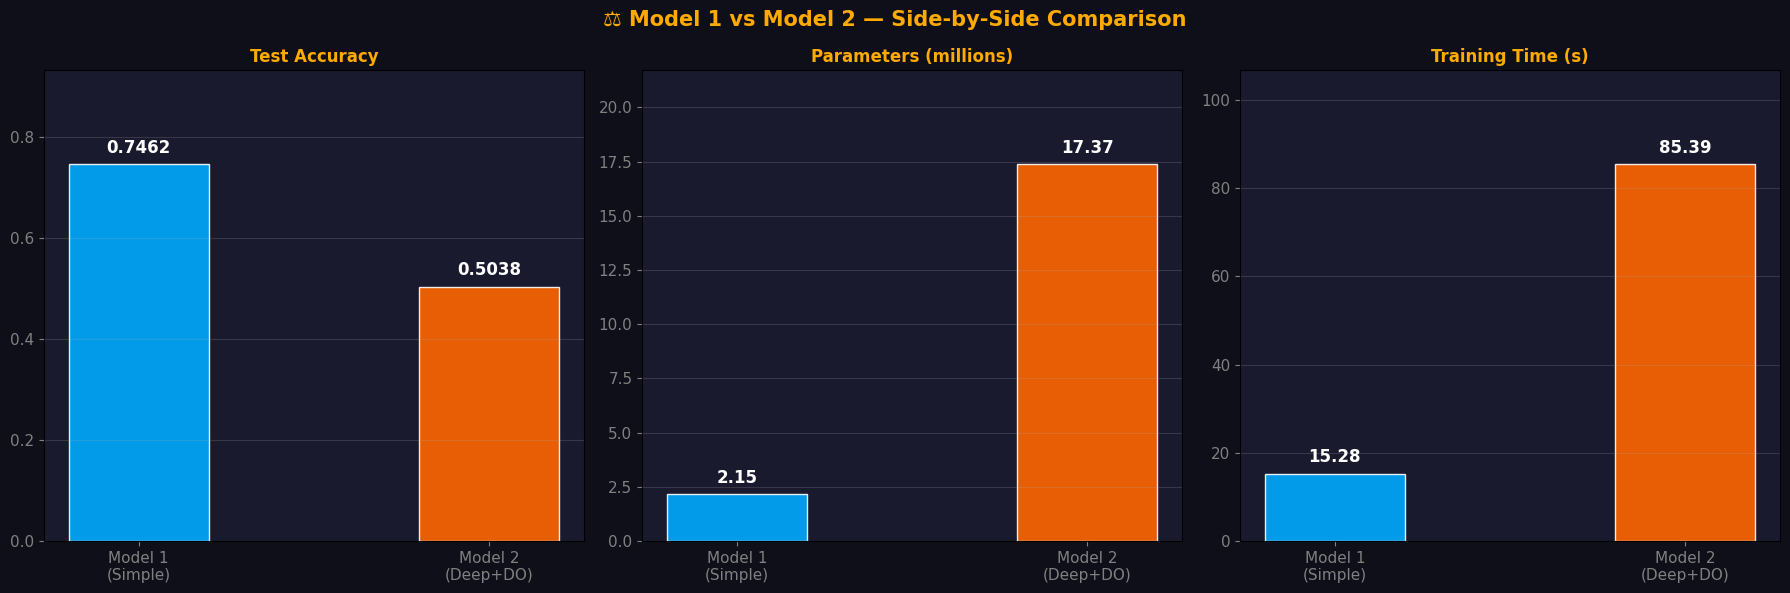


📊 COMPARISON TABLE
Metric                          Model 1              Model 2       
----------------------------------------------------------------------
Parameters                     2,153,729            17,369,409     
Test Accuracy                    74.62%               50.38%       
Training Time                    15.3s                85.4s        
Dropout                            No           Yes (0.25/0.5/0.3) 
BatchNorm                          No                  Yes         

🏆 Winner: Model 1  (acc: Model1=74.62% vs Model2=50.38%)


In [ ]:
# ============================================================
# SECTION 24: MODEL COMPARISON
# ============================================================

y_pred2 = (model2.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
acc2     = accuracy_score(y_test.astype(int), y_pred2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')

compare = {
  'Test Accuracy':        [acc1, acc2],
  'Parameters (millions)':[model1.count_params()/1e6, model2.count_params()/1e6],
  'Training Time (s)':    [time1, time2],
}
c1,c2='#00aaff','#ff6600'
labels=['Model 1\n(Simple)','Model 2\n(Deep+DO)']

for idx,(metric,vals) in enumerate(compare.items()):
  ax=axes[idx]; ax.set_facecolor('#1a1a2e')
  bars=ax.bar(labels, vals, color=[c1,c2], edgecolor='white', width=0.4, alpha=0.9)
  ax.set_title(metric, color='#ffaa00', fontsize=12, fontweight='bold')
  ax.tick_params(colors='gray', labelsize=11)
  ax.grid(True, alpha=0.2, axis='y')
  for bar,v in zip(bars,vals):
      fmt=f'{v:.4f}' if 'Acc' in metric else f'{v:.2f}'
      ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*.02,
              fmt,ha='center',va='bottom',color='white',fontsize=12,fontweight='bold')
  ax.set_ylim(0, max(vals)*1.25)

plt.suptitle('⚖️ Model 1 vs Model 2 — Side-by-Side Comparison',
           fontsize=15, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📊 COMPARISON TABLE")
print("="*70)
print(f"{'Metric':<25} {'Model 1':^20} {'Model 2':^20}")
print("-"*70)
for name,vals in [
  ('Parameters',         [f"{model1.count_params():,}", f"{model2.count_params():,}"]),
  ('Test Accuracy',      [f"{acc1*100:.2f}%",          f"{acc2*100:.2f}%"]),
  ('Training Time',      [f"{time1:.1f}s",             f"{time2:.1f}s"]),
  ('Dropout',            ['No',                        'Yes (0.25/0.5/0.3)']),
  ('BatchNorm',          ['No',                        'Yes']),
]:
  print(f"{name:<25} {vals[0]:^20} {vals[1]:^20}")
print("="*70)
winner = "Model 2" if acc2>acc1 else "Model 1"
print(f"\n🏆 Winner: {winner}  (acc: Model1={acc1*100:.2f}% vs Model2={acc2*100:.2f}%)")

---
    # 🔷 SECTION 25: Visualize CNN Filters & SECTION 26: Feature Maps

    ---

    ## What Do Filters Learn?

    | Layer | What filters detect |
    |-------|-------------------|
    | Conv Layer 1 | Edges, colors, gradients |
    | Conv Layer 2 | Curves, corners, textures |
    | Conv Layer 3 | Complex shapes, patterns |

    Feature maps show **where in the image** each filter activated strongly.
    

Conv Layer 1 filters shape: (3, 3, 3, 32)
  = (32 filters, each 3×3×3)


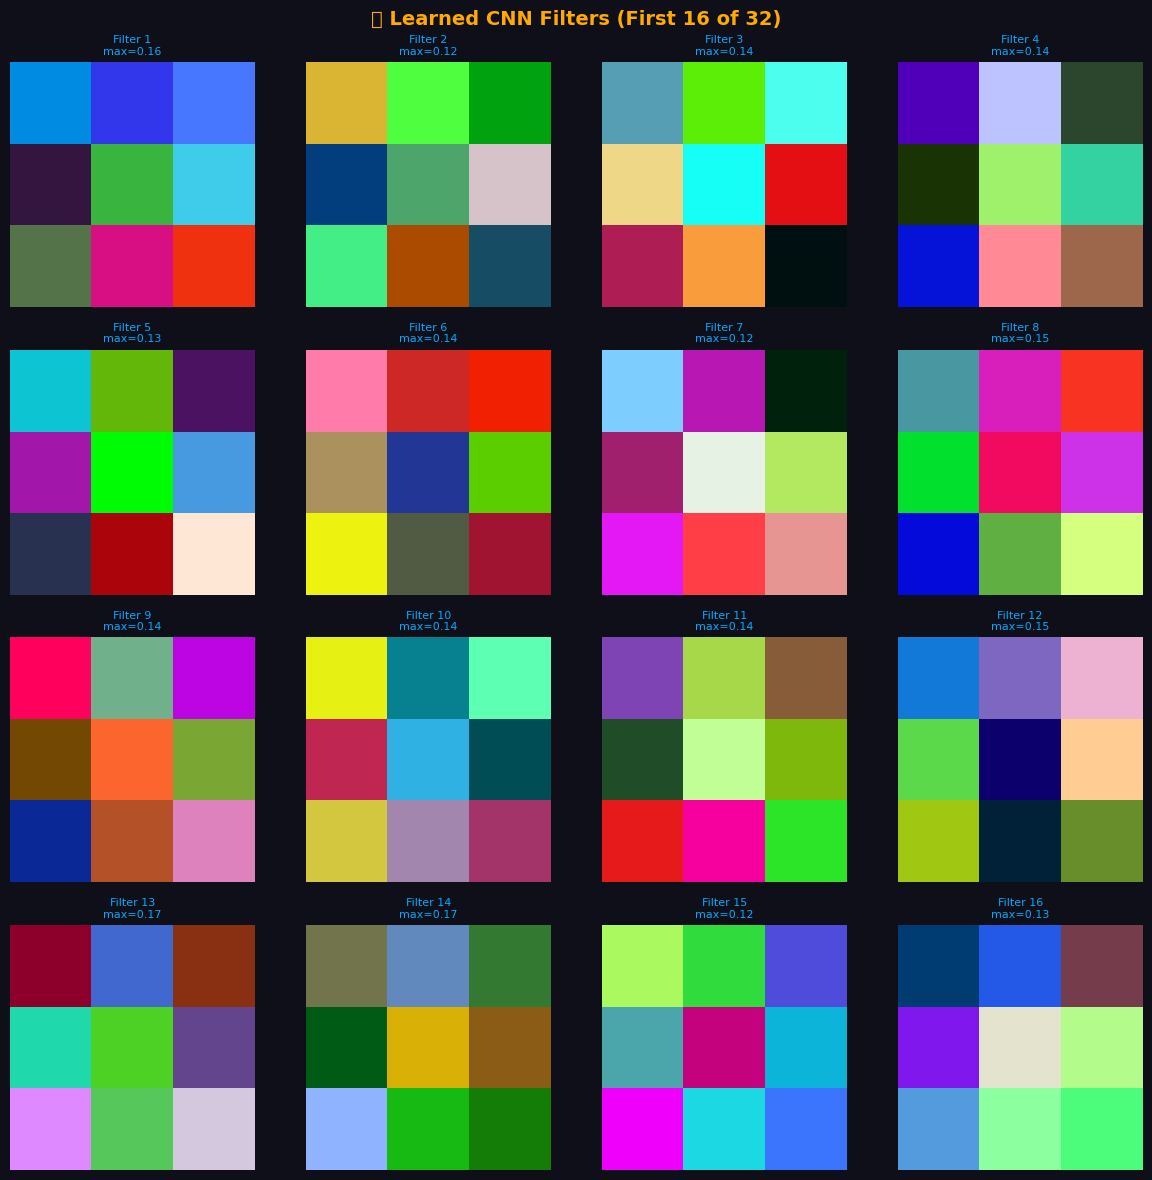


📊 Feature map shapes across all conv layers:
  Layer 1 (b1_conv): (1, 128, 128, 32) → 32 feature maps of 128×128
  Layer 2 (b2_conv): (1, 64, 64, 64) → 64 feature maps of 64×64
  Layer 3 (b3_conv): (1, 32, 32, 64) → 64 feature maps of 32×32


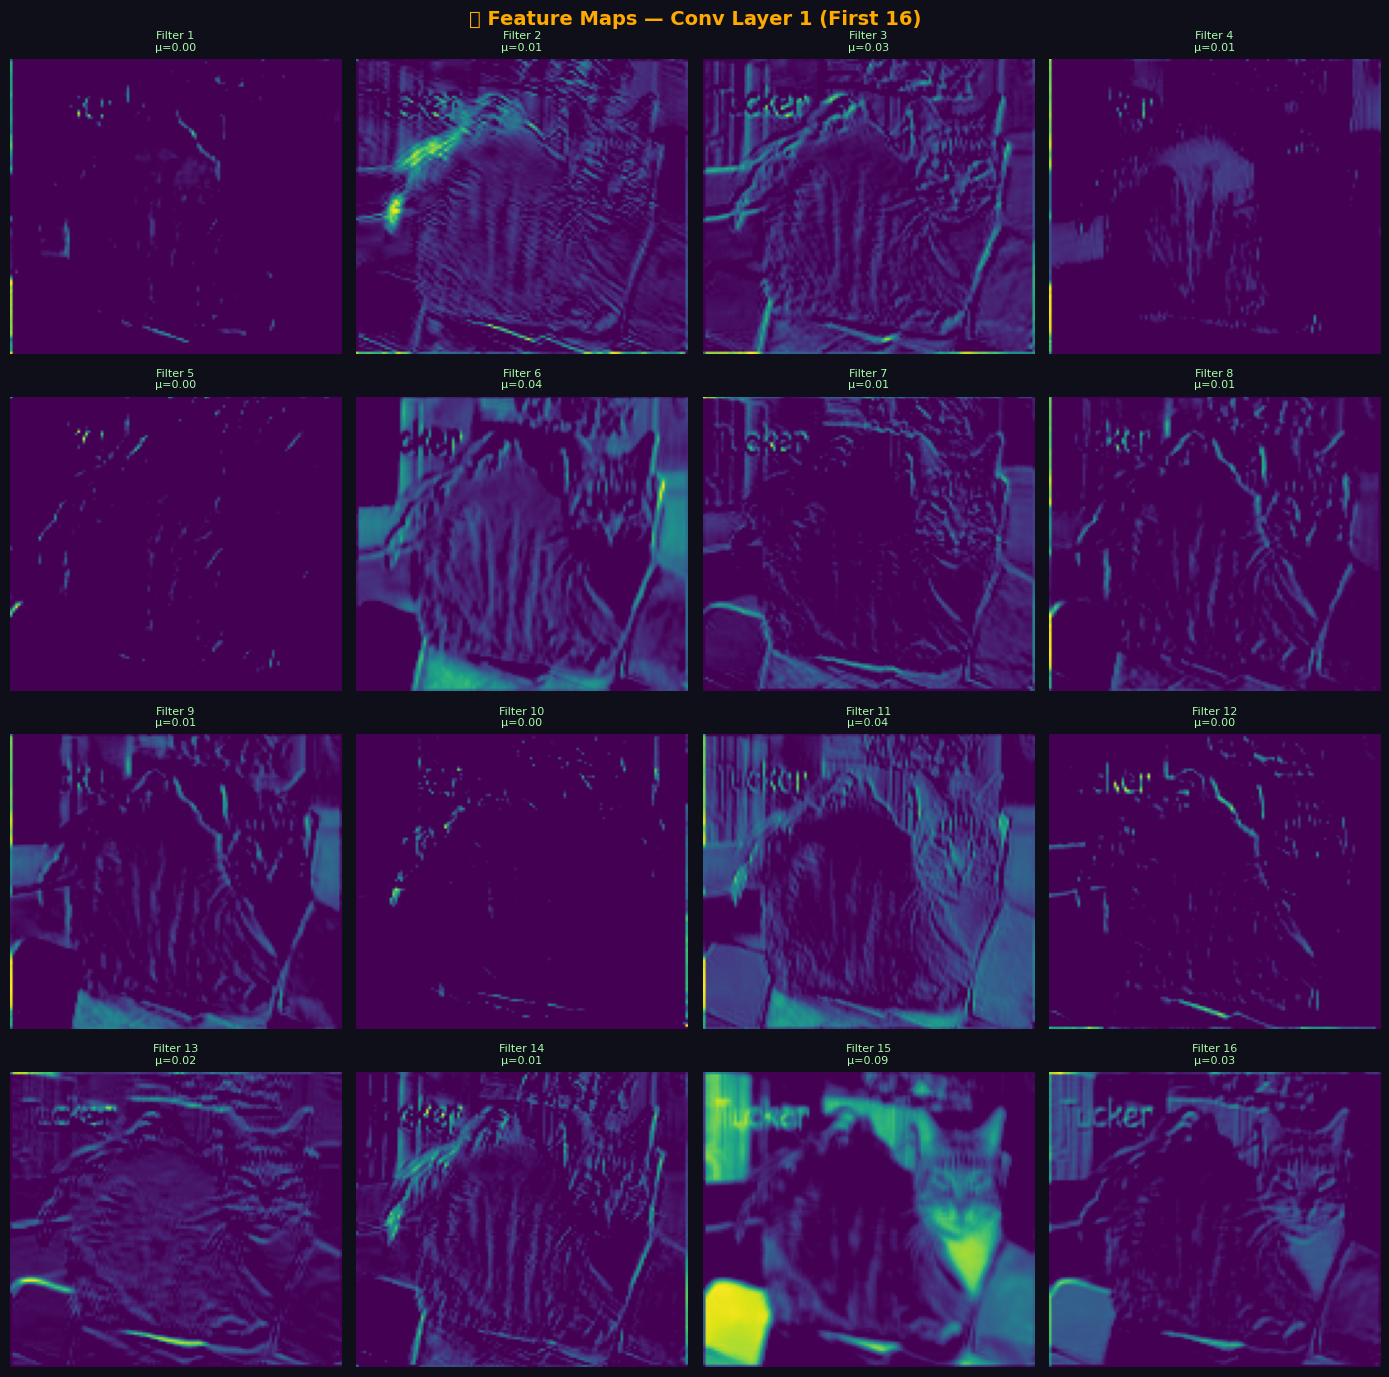

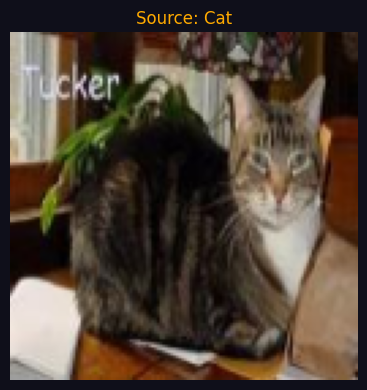

In [ ]:
# ============================================================
# SECTIONS 25-26: FILTERS AND FEATURE MAPS
# ============================================================

# ── SECTION 25: FILTER WEIGHTS ───────────────────────────
conv1 = model1.get_layer('b1_conv')
filters, biases = conv1.get_weights()
print(f"Conv Layer 1 filters shape: {filters.shape}")
print(f"  = ({filters.shape[3]} filters, each {filters.shape[0]}×{filters.shape[1]}×{filters.shape[2]})")

n_show = min(16, filters.shape[3])
fig, axes = plt.subplots(4, 4, figsize=(12,12))
fig.patch.set_facecolor('#0f0f1a')

for i in range(n_show):
  ax = axes[i//4, i%4]
  f = filters[:,:,:,i]
  f_disp = (f-f.min())/(f.max()-f.min()+1e-8)
  ax.imshow(f_disp)
  ax.set_title(f'Filter {i+1}\nmax={f.max():.2f}',
               color='#00aaff', fontsize=8)
  ax.axis('off')

plt.suptitle('🔍 Learned CNN Filters (First 16 of 32)',
           fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

# ── SECTION 26: FEATURE MAPS ─────────────────────────────
# Ensure model has been built by calling it once
model1(np.zeros((1, 128, 128, 3)))

conv_layers = [l for l in model1.layers if isinstance(l, layers.Conv2D)]
act_model   = tf.keras.Model(inputs=model1.inputs,
                           outputs=[l.output for l in conv_layers])

sample = X_test[0:1]
acts   = act_model.predict(sample, verbose=0)

print(f"\n📊 Feature map shapes across all conv layers:")
for i,(l,a) in enumerate(zip(conv_layers,acts)):
  print(f"  Layer {i+1} ({l.name}): {a.shape} → {a.shape[3]} feature maps of {a.shape[1]}×{a.shape[2]}")

# Show first layer's feature maps
fmaps = acts[0]  # (1, H, W, 32)
n_maps = min(16, fmaps.shape[3])
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.patch.set_facecolor('#0f0f1a')

for i in range(n_maps):
  ax = axes[i//4, i%4]
  fm = fmaps[0,:,:,i]
  ax.imshow(fm, cmap='viridis', aspect='auto')
  ax.set_title(f'Filter {i+1}\nμ={fm.mean():.2f}', color='#aaffaa', fontsize=8)
  ax.axis('off')

plt.suptitle('🗺️ Feature Maps — Conv Layer 1 (First 16)',
           fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

# Show original image
fig2, ax2 = plt.subplots(figsize=(4,4))
fig2.patch.set_facecolor('#0f0f1a')
ax2.imshow(sample[0]); ax2.axis('off')
ax2.set_title(f'Source: {CATEGORIES[int(y_test[0])]}', color='#ffaa00', fontsize=12)
plt.tight_layout(); plt.show()

---
    # 🔷 SECTION 27: Overfitting, Underfitting & Regularization

    ---

    ## Bias-Variance Tradeoff

    | Scenario | Train Acc | Val Acc | Problem |
    |----------|-----------|---------|---------|
    | Underfitting | Low | Low | Model too simple |
    | Good Fit | High | High ≈ Train | ✅ Perfect! |
    | Overfitting | Very High | Low | Memorized training set |

    ---

    ## Fixes for Overfitting

    1. **Dropout** — randomly zero neurons during training
    2. **Batch Normalization** — normalizes layer inputs
    3. **Data Augmentation** — artificial variety in training data
    4. **L2 Regularization** — penalizes large weights: $L_{\text{reg}} = L + \lambda\|W\|^2$
    5. **Early Stopping** — stop before val_loss starts rising
    6. **More data** — best solution if available

    ---

    ## Dropout: How It Works

    ```
    TRAINING:     INFERENCE:
    [n1][n2][n3]  [n1][n2][n3]   ← All neurons ON
    |  |  |       |  |  |
    [n4][XX][n6]  [n4][n5][n6]   ← Scale by (1-p)
       ↑
    Randomly killed (p=0.5)
    ```
    

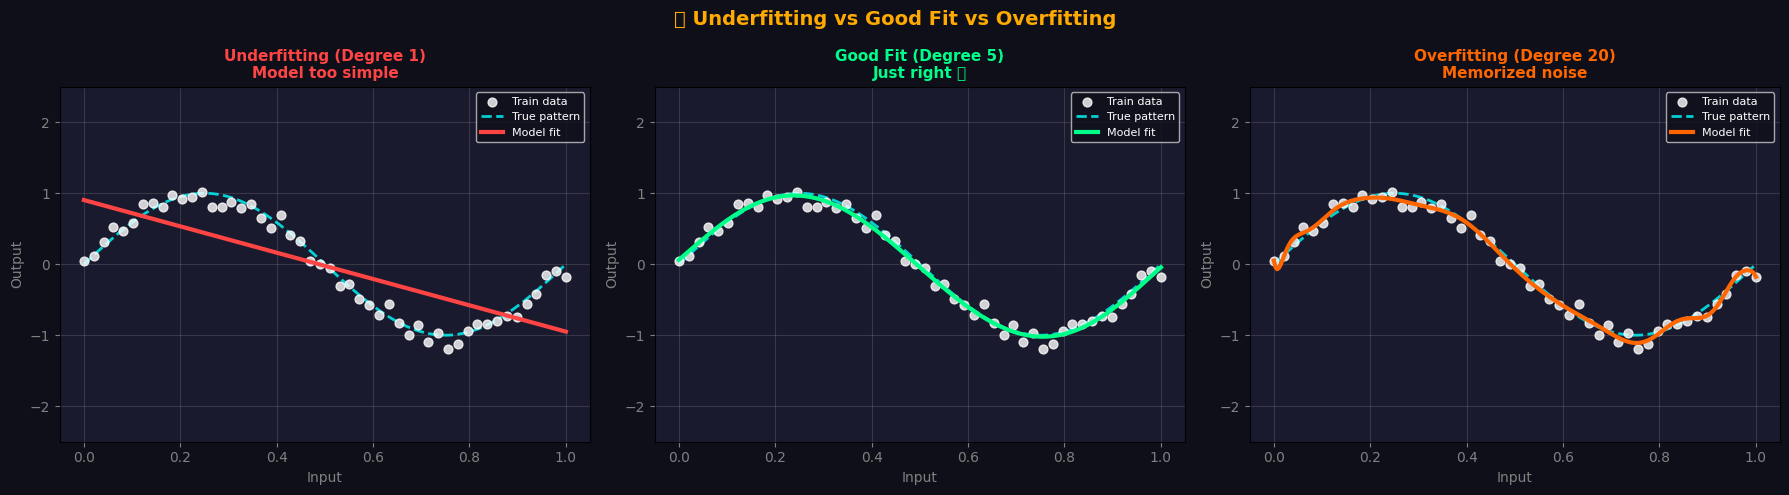

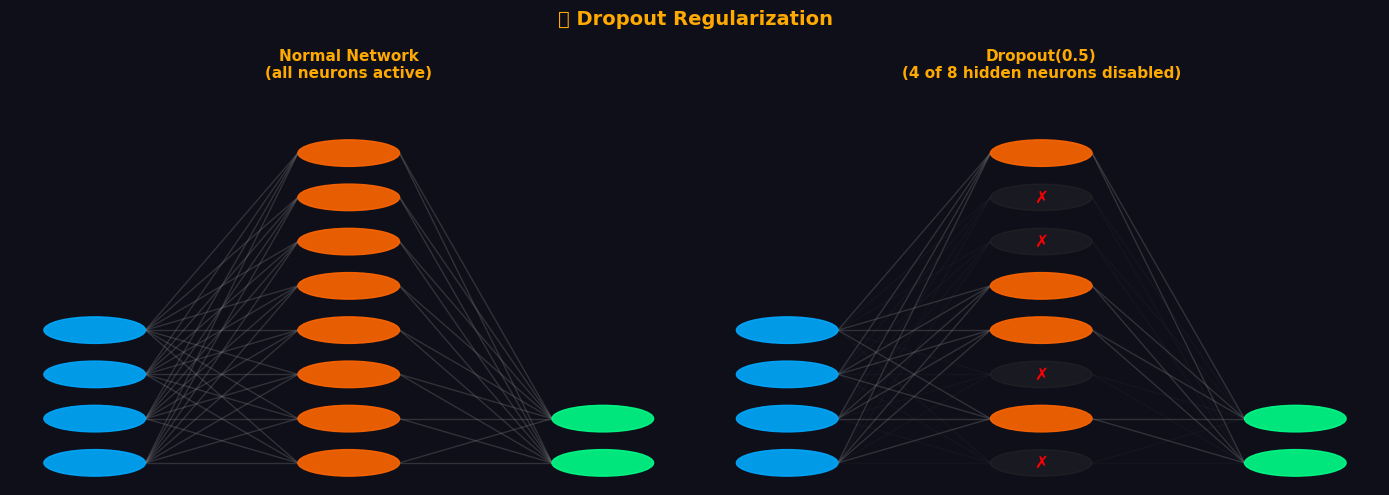

In [ ]:
# ============================================================
# SECTION 27: OVERFITTING VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x_data = np.linspace(0, 1, 50)
y_data = np.sin(2*np.pi*x_data) + 0.1*np.random.randn(50)
x_sm   = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for idx,(deg,color,title) in enumerate([
  (1,  '#ff4444', 'Underfitting (Degree 1)\nModel too simple'),
  (5,  '#00ff88', 'Good Fit (Degree 5)\nJust right ✅'),
  (20, '#ff6600', 'Overfitting (Degree 20)\nMemorized noise'),
]):
  ax = axes[idx]; ax.set_facecolor('#1a1a2e')
  c  = np.polyfit(x_data, y_data, deg)
  yf = np.polyval(c, x_sm)

  ax.scatter(x_data, y_data, color='white', s=40, zorder=3, alpha=0.8, label='Train data')
  ax.plot(x_sm, np.sin(2*np.pi*x_sm), 'cyan', linewidth=2, linestyle='--',
          label='True pattern', zorder=2, alpha=0.8)
  ax.plot(x_sm, yf, color=color, linewidth=3, label='Model fit', zorder=4)

  ax.set_title(title, color=color, fontsize=11, fontweight='bold')
  ax.set_xlabel('Input', color='gray'); ax.set_ylabel('Output', color='gray')
  ax.tick_params(colors='gray')
  ax.legend(fontsize=8, labelcolor='white', facecolor='#0f0f1a')
  ax.set_ylim(-2.5, 2.5); ax.grid(True, alpha=0.2)

plt.suptitle('🎯 Underfitting vs Good Fit vs Overfitting',
           fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

# Dropout network visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

np.random.seed(7)
dropped = set(np.random.choice(8, 4, replace=False))

layer_pos = [[(0,i) for i in range(4)],
           [(1.5,i) for i in range(8)],
           [(3,i) for i in range(2)]]
layer_colors = ['#00aaff','#ff6600','#00ff88']

def draw_net(ax, drop_set, title):
  ax.set_facecolor('#1a1a2e')
  ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 8.5)
  ax.axis('off')
  for li,(layer,lc) in enumerate(zip(layer_pos, layer_colors)):
      for ni,(x,y) in enumerate(layer):
          killed = (drop_set is not None and li==1 and ni in drop_set)
          cc = '#333333' if killed else lc
          circ = plt.Circle((x,y), 0.3, color=cc, alpha=0.3 if killed else 0.9, zorder=3)
          ax.add_patch(circ)
          if killed: ax.text(x,y,'✗',ha='center',va='center',color='red',fontsize=12,fontweight='bold',zorder=4)
          if li>0:
              for pni,(px,py) in enumerate(layer_pos[li-1]):
                  pd = (drop_set is not None and li-1==1 and pni in drop_set)
                  alp = 0.05 if (killed or pd) else 0.3
                  ax.plot([px+0.3,x-0.3],[py,y],'gray',alpha=alp,linewidth=1,zorder=1)
  ax.set_title(title, color='#ffaa00', fontsize=11, fontweight='bold')

draw_net(axes[0], None, "Normal Network\n(all neurons active)")
draw_net(axes[1], dropped, "Dropout(0.5)\n(4 of 8 hidden neurons disabled)")

plt.suptitle('💉 Dropout Regularization', fontsize=14, color='#ffaa00', fontweight='bold')
plt.tight_layout(); plt.show()

---
    # 🔷 SECTION 28: Saving and Loading Models

    ---

    | Format | Extension | Notes |
    |--------|-----------|-------|
    | Keras native | `.keras` | Recommended ✅ |
    | HDF5 | `.h5` | Legacy, widely supported |
    | SavedModel | (folder) | TensorFlow deployment |
    

In [ ]:
# ============================================================
# SECTION 28: SAVE AND LOAD MODELS
# ============================================================

import os

# Save .keras (recommended)
model1.save("cnn_model1.keras")
size_keras = os.path.getsize("cnn_model1.keras")/1024
print(f"✅ Saved .keras  : {size_keras:.1f} KB")

# Save .h5 (legacy)
model1.save("cnn_model1.h5")
size_h5 = os.path.getsize("cnn_model1.h5")/1024
print(f"✅ Saved .h5     : {size_h5:.1f} KB")

# Load and verify
loaded = tf.keras.models.load_model("cnn_model1.keras")
print(f"\n✅ Loaded from .keras successfully")
print(f"   Input:  {loaded.input_shape}")
print(f"   Output: {loaded.output_shape}")

# Verify predictions match
orig = model1.predict(X_test[:3], verbose=0)
load = loaded.predict(X_test[:3], verbose=0)
print(f"\n🔍 Prediction match check (first 3 samples):")
for i,(o,l) in enumerate(zip(orig,load)):
  match = abs(o[0]-l[0]) < 1e-5
  print(f"  Sample {i}: original={o[0]:.6f}  loaded={l[0]:.6f}  {'✅' if match else '❌'}")

print("""
\n📌 How to save/load in your own project:
# Save
model.save('my_cat_dog_model.keras')

# Load & predict
from tensorflow import keras
model = keras.models.load_model('my_cat_dog_model.keras')
pred  = model.predict(new_image_array)
""")

✅ Saved .keras  : 25283.3 KB
✅ Saved .h5     : 25284.2 KB

✅ Loaded from .keras successfully
   Input:  (None, 128, 128, 3)
   Output: (None, 1)

🔍 Prediction match check (first 3 samples):
  Sample 0: original=0.066810  loaded=0.066810  ✅
  Sample 1: original=0.814153  loaded=0.814153  ✅
  Sample 2: original=0.172654  loaded=0.172654  ✅


📌 How to save/load in your own project:
# Save
model.save('my_cat_dog_model.keras')

# Load & predict
from tensorflow import keras
model = keras.models.load_model('my_cat_dog_model.keras')
pred  = model.predict(new_image_array)



---
    # 🔷 SECTION 29: Student Activities — 15 Practical Exercises

    ---

    ### ✏️ Activity 1: Change Activation Function
    Modify Model 1: replace `relu` → `tanh` in all Conv layers. Compare accuracy.
    ```python
    # TODO: In build_model1(), change activation='relu' → activation='tanh'
    # Retrain and compare val accuracy. Which is better?
    ```

    ### ✏️ Activity 2: Change Optimizer
    Train with SGD instead of Adam.
    ```python
    model.compile(optimizer=tf.keras.optimizers.SGD(0.01, momentum=0.9), ...)
    # Question: How many epochs does SGD need to match Adam?
    ```

    ### ✏️ Activity 3: Increase Epochs to 50
    Does accuracy improve after epoch 20? When does overfitting start?

    ### ✏️ Activity 4: Add Another Conv Block
    Add a 4th Conv+Pool block to Model 1 before Flatten.
    ```python
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    ```

    ### ✏️ Activity 5: Train on Grayscale Images
    ```python
    # Preprocess: img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).reshape(128,128,1)
    # Change model input: Input(shape=(128,128,1))
    # Question: Is RGB or Grayscale better for this task?
    ```

    ### ✏️ Activity 6: Try 64×64 Image Size
    Change IMG_SIZE = 64 and retrain. Compare speed, memory, accuracy.

    ### ✏️ Activity 7: Add L2 Regularization
    ```python
    from tensorflow.keras.regularizers import l2
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001))
    ```

    ### ✏️ Activity 8: Data Augmentation with ImageDataGenerator
    ```python
    datagen = ImageDataGenerator(rotation_range=20, horizontal_flip=True, zoom_range=0.2)
    datagen.fit(X_train_f)
    model.fit(datagen.flow(X_train_f, y_train_f, batch_size=32),
            validation_data=(X_val, y_val), epochs=20)
    ```

    ### ✏️ Activity 9: Learning Rate Comparison
    Train with LR = [0.01, 0.001, 0.0001]. Plot 3 accuracy curves on one graph.

    ### ✏️ Activity 10: Batch Size Experiment
    Try batch sizes [8, 16, 32, 64]. Record training time and final accuracy.

    ### ✏️ Activity 11: Transfer Learning (VGG16)
    ```python
    base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model_vgg = tf.keras.Model(inputs=base.input, outputs=out)
    ```

    ### ✏️ Activity 12: Visualize All Misclassified Images
    ```python
    wrong = np.where(y_pred1 != y_test.astype(int))[0]
    # Display all wrong[: min(20, len(wrong))] images with true/predicted labels
    # What patterns do you notice in wrong predictions?
    ```

    ### ✏️ Activity 13: Grad-CAM Heatmap
    Implement Gradient-weighted Class Activation Mapping on test images to highlight which regions drive predictions.

    ### ✏️ Activity 14: 3-class Extension (Cat / Dog / Other)
    Modify: Dense(3, softmax), loss='sparse_categorical_crossentropy'

    ### ✏️ Activity 15: Real-Time Webcam Prediction
    ```python
    import cv2
    cap = cv2.VideoCapture(0)
    while True:
      ret, frame = cap.read()
      img = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (128,128))
      img_n = img.astype(np.float32)/255.0
      pred = model1.predict(img_n[np.newaxis], verbose=0)[0][0]
      label = f"{'Dog' if pred>=0.5 else 'Cat'} {max(pred,1-pred)*100:.1f}%"
      cv2.putText(frame, label, (20,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
      cv2.imshow('Cat vs Dog', frame)
      if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release(); cv2.destroyAllWindows()
    ```
    

---
    # 🔷 SECTION 30: 30 CNN Interview Questions

    ---

    ## 🟢 BEGINNER (Q1–Q10)

    **Q1. What does CNN stand for, and what makes it special for images?**  
    A: Convolutional Neural Network. Special because: (1) local connectivity (filters see small regions), (2) weight sharing (same filter reused across image), (3) translation invariance (detects patterns anywhere).

    **Q2. What is a convolution operation mathematically?**  
    A: $\text{Output}[i,j]=\sum_{m,n}\text{Input}[i+m,j+n]\times\text{Kernel}[m,n]+b$. A filter slides over the input computing dot products to produce a feature map.

    **Q3. What is the difference between VALID and SAME padding?**  
    A: VALID=no padding (output smaller than input). SAME=zero-pad borders so output has same spatial size as input.

    **Q4. How is output size calculated?**  
    A: $\text{out} = \lfloor(\text{in} - K)/S\rfloor + 1$ (no padding). With SAME padding: out = in/stride.

    **Q5. Why use Max Pooling instead of stride 2 convolution?**  
    A: Both downsample, but Max Pooling has no learnable parameters, is computationally cheaper, and explicitly keeps the strongest activation. Strided conv is learnable and sometimes better.

    **Q6. What does the Flatten layer do?**  
    A: Reshapes 3D tensor (H×W×C) to 1D vector (H×W×C,) for Dense layers. No parameters learned.

    **Q7. What loss function is used for binary classification?**  
    A: Binary Cross-Entropy: $L=-[y\log\hat{y}+(1-y)\log(1-\hat{y})]$

    **Q8. What is the purpose of model.compile()?**  
    A: Sets optimizer (how weights update), loss (what to minimize), and metrics (what to track).

    **Q9. What does model.fit() do?**  
    A: Runs the training loop: forward pass → compute loss → backward pass → update weights, for the specified epochs and batch size.

    **Q10. What is the range of Sigmoid output, and when do we use it?**  
    A: Range (0,1). Used in the output layer for binary classification to get a probability.

    ---

    ## 🟡 INTERMEDIATE (Q11–Q20)

    **Q11. Why does CNN have fewer parameters than a fully connected network?**  
    A: Weight sharing (same filter reused) + local connectivity (filter sees only local region). A 3×3 filter on 128×128×3 image = 27 params vs 49,152 for a dense connection.

    **Q12. What is the dying ReLU problem and its solution?**  
    A: Neurons outputting 0 for all inputs → gradient = 0 → never update. Solutions: Leaky ReLU (slope 0.01 for negatives), ELU, He initialization, lower learning rate.

    **Q13. What does Batch Normalization do?**  
    A: Normalizes layer inputs to mean≈0, std≈1 per batch. Enables higher LR, reduces gradient vanishing, mild regularization. Formula: $\hat{x}=(x-\mu_B)/(\sigma_B+\epsilon)$

    **Q14. How does Dropout prevent overfitting?**  
    A: Randomly deactivates p% of neurons each forward pass, preventing co-adaptation. Forces network to learn redundant representations. At test time: all neurons active, outputs scaled by (1-p).

    **Q15. What is the vanishing gradient problem?**  
    A: In deep networks, gradients shrink exponentially during backprop through many sigmoid/tanh layers. Early layers learn extremely slowly. Solved by: ReLU, BatchNorm, skip connections, gradient clipping.

    **Q16. What is transfer learning and when should you use it?**  
    A: Reusing weights pretrained on a large dataset (e.g., ImageNet) for a new task. Use when: limited data, similar domain, GPU-limited. Modes: feature extraction (freeze base) or fine-tuning (train all).

    **Q17. Explain the chain rule in backpropagation.**  
    A: Gradients for early layers are computed by chaining derivatives: $\partial L/\partial W_1 = (\partial L/\partial \hat{y})(\partial \hat{y}/\partial z)(\partial z/\partial W_1)$. TensorFlow's autograd computes this automatically.

    **Q18. What are Keras callbacks?**  
    A: Functions called at training events. Key callbacks: EarlyStopping (stop if val_loss stagnates), ModelCheckpoint (save best model), ReduceLROnPlateau (halve LR when stuck), TensorBoard (visualize training).

    **Q19. How do you handle class imbalance?**  
    A: class_weight={'0': 1.0, '1': 5.0}, oversampling (duplicate minority), undersampling, focal loss, data augmentation for minority class.

    **Q20. What is the receptive field in CNN?**  
    A: The area of the input image that influences one output neuron. Grows with depth: two 3×3 conv layers → 5×5 receptive field. Deeper networks "see" more of the image per neuron.

    ---

    ## 🔴 ADVANCED (Q21–Q30)

    **Q21. How does ResNet solve the degradation problem?**  
    A: Skip connections: output = F(x) + x. Gradients flow directly through skip connections, preventing vanishing. Even very deep networks (152 layers) can be trained stably.

    **Q22. What is depthwise separable convolution?**  
    A: Splits conv into: (1) depthwise (one filter per input channel — spatial features) + (2) pointwise (1×1 conv — channel combination). 8-9× fewer params. Used in MobileNet, EfficientNet.

    **Q23. What does a 1×1 convolution accomplish?**  
    A: Cross-channel linear combinations without spatial operation. Uses: channel reduction (bottleneck), adding non-linearity cheaply, changing number of channels. Used extensively in Inception, ResNet.

    **Q24. What is Grad-CAM?**  
    A: Gradient-weighted Class Activation Mapping. Computes gradient of class score w.r.t. last conv layer's feature maps, weights them, and overlays as a heatmap on the original image. Shows model's "attention."

    **Q25. Explain the Inception module (GoogLeNet).**  
    A: Parallel branches with 1×1, 3×3, 5×5 conv and max pool. Outputs concatenated across channels. Captures features at multiple scales simultaneously with 1×1 convolutions to reduce computation.

    **Q26. What is knowledge distillation?**  
    A: Training a small "student" model to mimic a large "teacher" model's soft probability outputs. Student matches teacher's class probability distribution (soft labels), not just hard labels.

    **Q27. What is the difference between instance and batch normalization?**  
    A: Batch norm: normalizes across batch dimension for each channel. Instance norm: normalizes each sample-channel pair independently. Instance norm better for style transfer; batch norm better for classification.

    **Q28. How do Vision Transformers (ViT) differ from CNNs?**  
    A: ViT splits image into fixed patches, encodes as tokens, applies self-attention (global receptive field from layer 1). CNNs have local receptive fields growing with depth. ViT needs more data but scales better.

    **Q29. What is Non-Maximum Suppression (NMS) in object detection?**  
    A: Removes duplicate bounding box proposals. Keeps the box with highest confidence; suppresses overlapping boxes with IoU above threshold. Critical post-processing in YOLO, Faster R-CNN.

    **Q30. Explain label smoothing and its benefit.**  
    A: Instead of hard targets [0,1], use soft targets [0.05, 0.95]. Prevents overconfidence, improves calibration, acts as regularization. Formula: y_smooth = y*(1-ε) + ε/K.
    

---
    # 🔷 SECTION 31: 20-Question MCQ Quiz (with Answers)

    ---

    **Q1.** What does "CNN" stand for?  
    a) Computational Node Network | **b) Convolutional Neural Network ✅** | c) Connected Neuron Net | d) Cyclic Number Network

    **Q2.** Output of a single convolution filter is called:  
    a) Weight map | **b) Feature map ✅** | c) Bias vector | d) Kernel matrix

    **Q3.** Input 7×7, kernel 3×3, stride 1, no padding. Output size?  
    a) 7×7 | b) 6×6 | **c) 5×5 ✅** | d) 4×4  
    *(Formula: (7-3)/1+1 = 5)*

    **Q4.** Which activation outputs values strictly between 0 and 1?  
    a) ReLU | **b) Sigmoid ✅** | c) Tanh | d) Linear

    **Q5.** ReLU(−3.5) = ?  
    **a) 0 ✅** | b) −3.5 | c) 3.5 | d) 0.5

    **Q6.** Max pooling with 2×2 pool on a 6×6 input (stride 2) gives:  
    a) 6×6 | **b) 3×3 ✅** | c) 4×4 | d) 2×2

    **Q7.** Why do we normalize images by dividing by 255?  
    a) To make them grayscale | b) To reduce file size | **c) To scale values 0–1 for stable training ✅** | d) To speed up loading

    **Q8.** Dropout(0.5) during training:  
    a) Halves the learning rate | **b) Disables 50% of neurons randomly ✅** | c) Keeps 50% of training data | d) Sets 50% of weights to zero permanently

    **Q9.** Model output: 0.72. True label: Dog (=1). Is prediction correct?  
    **a) Yes (Dog, 72% confidence) ✅** | b) No (Cat) | c) Uncertain | d) Need more info

    **Q10.** Which optimizer adapts the learning rate per parameter?  
    a) SGD | b) Momentum | **c) Adam ✅** | d) Batch GD

    **Q11.** Flatten(4×4×32) output shape?  
    a) (32,) | b) (16,) | **c) (512,) ✅** | d) (128,)  
    *(4×4×32 = 512)*

    **Q12.** Training accuracy 97%, validation 58%. Problem?  
    a) Underfitting | **b) Overfitting ✅** | c) Learning rate too low | d) Wrong activation

    **Q13.** He initialization is designed for which activation?  
    a) Sigmoid | b) Tanh | **c) ReLU ✅** | d) Softmax

    **Q14.** Binary cross-entropy with y=1, ŷ=0.95. Approximate loss?  
    **a) ≈0.05 (small, good prediction) ✅** | b) ≈0.5 | c) ≈2.0 | d) ≈1.0

    **Q15.** What does Batch Normalization normalize per batch?  
    a) Input images | **b) Layer activations ✅** | c) Weight matrices | d) Loss values

    **Q16.** In CNN, "weight sharing" means:  
    a) Two models share a GPU | **b) Same filter weights used at all positions ✅** | c) Weights are divided by batch size | d) Biases are shared across layers

    **Q17.** Which is NOT a CNN? (LSTM / VGG16 / ResNet / MobileNet)  
    **a) LSTM ✅** | b) VGG16 | c) ResNet | d) MobileNet  
    *(LSTM = Recurrent Neural Network)*

    **Q18.** Softmax output: [0.1, 0.7, 0.2]. Predicted class?  
    a) Class 0 | **b) Class 1 ✅** | c) Class 2 | d) All equal

    **Q19.** model.evaluate() returns:  
    a) Weight updates | **b) Loss and accuracy on given data ✅** | c) Training history | d) Confusion matrix

    **Q20.** Best metric when classes are imbalanced:  
    a) Accuracy only | b) Training loss | **c) F1 Score / AUC-ROC ✅** | d) Number of parameters
    

---
    # 🔷 SECTION 32: 10 Project Assignments

    ---

    ### 📝 Assignment 1: Flower Classification (Beginner)
    Classify 5 flower types: daisy, dandelion, rose, sunflower, tulip.  
    **Dataset:** TF Flowers (`tf.keras.utils.get_file`)  
    **Goal:** >75% val accuracy. Show confusion matrix.

    ---

    ### 📝 Assignment 2: MNIST Digit Recognition (Beginner)
    Classify handwritten digits 0–9 using CNN.  
    **Dataset:** `tf.keras.datasets.mnist`  
    **Goal:** >99% accuracy. Visualize all misclassified digits.

    ---

    ### 📝 Assignment 3: CIFAR-10 (Intermediate)
    Classify 10 objects: airplane, car, bird, cat, deer, dog, frog, horse, ship, truck.  
    **Goal:** Train with and without data augmentation, compare results.

    ---

    ### 📝 Assignment 4: Medical Imaging (Intermediate)
    Chest X-ray classification: Normal vs Pneumonia.  
    **Key:** Handle class imbalance. Report recall for Pneumonia class (higher recall = fewer missed cases).

    ---

    ### 📝 Assignment 5: Emotion Recognition (Intermediate)
    Classify 7 facial expressions from FER-2013 dataset (48×48 grayscale).  
    **Goal:** Implement Grad-CAM to visualize what the model looks at.

    ---

    ### 📝 Assignment 6: Transfer Learning Battle (Intermediate–Advanced)
    Train on Dogs vs Cats using:
    - CNN from scratch
    - VGG16 feature extraction (frozen base)
    - VGG16 fine-tuning (unfreeze top layers)  
    **Compare:** accuracy, training time, parameters.

    ---

    ### 📝 Assignment 7: Data Augmentation Study (Advanced)
    Train the same model 5× with different augmentation levels. Plot all 5 validation accuracy curves. Determine minimum augmentation needed for good generalization.

    ---

    ### 📝 Assignment 8: Model Size vs Accuracy Tradeoff (Advanced)
    Train 5 models of increasing size (depth/width). Plot: parameters vs val accuracy. Find the sweet spot.

    ---

    ### 📝 Assignment 9: CNN Explainability Dashboard (Advanced)
    Build an interactive Jupyter/Streamlit dashboard:
    - Upload any image
    - Run inference
    - Show: feature maps from each layer, Grad-CAM heatmap, confidence bar
    - Explain prediction in plain English

    ---

    ### 📝 Assignment 10: Real-Time Pet Detector (Advanced)
    Build a live webcam application:
    - Load trained model
    - Process each frame: preprocess → predict → annotate
    - Show: predicted class, confidence bar, FPS counter
    - Save annotated video output
    ```python
    import cv2
    cap = cv2.VideoCapture(0)
    fps_start = time.time()
    frame_count = 0
    while True:
      ret, frame = cap.read()
      # TODO: preprocess frame, predict, draw label
      frame_count += 1
      fps = frame_count / (time.time() - fps_start)
      cv2.putText(frame, f"FPS: {fps:.1f}", (10,30),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,0), 2)
      cv2.imshow('Live Cat vs Dog Detector', frame)
      if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release()
    cv2.destroyAllWindows()
    ```
    

---
    # 🔷 SECTION 33: Animations Index & Conclusion

    ---

    ## All Interactive Animations in This Notebook

    | # | Animation | Section | Type |
    |---|-----------|---------|------|
    | 1 | How computer sees an image (pixel grid) | Sec 1 | HTML/JS canvas |
    | 2 | CNN architecture layer explorer | Sec 6 | HTML/JS interactive |
    | 3 | Convolution sliding kernel | Sec 7 | HTML/JS animated |
    | 4 | Data augmentation variants | Sec 4 | HTML/JS canvas |
    | 5 | Weight initialization distributions | Sec 8 | Matplotlib histogram |
    | 6 | Bias effect on activation | Sec 9 | Matplotlib line plot |
    | 7 | Activation functions + derivatives | Sec 10 | Matplotlib |
    | 8 | Softmax probability conversion | Sec 10 | Matplotlib bar |
    | 9 | Max & Average Pooling | Sec 11 | Matplotlib heatmap |
    | 10 | RGB channel decomposition | Sec 3 | Matplotlib |
    | 11 | Image as matrix of numbers | Sec 5 | Matplotlib |
    | 12 | Gradient descent trajectory | Sec 16 | Matplotlib scatter |
    | 13 | Dropout network | Sec 27 | Matplotlib patch |
    | 14 | Overfitting vs underfitting | Sec 27 | Matplotlib |
    | 15 | Training accuracy/loss curves | Sec 20 | Matplotlib |

    ---

    ## 🎓 Congratulations on Completing This Manual!

    ### What You've Mastered:

    ✅ Computer Vision fundamentals  
    ✅ Image representation — pixels, RGB, matrices  
    ✅ Full CNN pipeline from input to output  
    ✅ Convolution mathematics — step by step  
    ✅ Weights, biases, activation functions  
    ✅ Pooling, flattening, dense layers  
    ✅ Forward propagation — manual calculation  
    ✅ Loss functions — Binary Cross-Entropy  
    ✅ Backpropagation and chain rule  
    ✅ Optimizers — Adam, SGD, RMSProp  
    ✅ Built CNN Model 1 (simple) and Model 2 (deep + Dropout)  
    ✅ Full evaluation — confusion matrix, F1, precision, recall  
    ✅ Visualized filters and feature maps  
    ✅ Overfitting, regularization, Dropout  
    ✅ Save and load models  
    ✅ 15 student activities  
    ✅ 30 interview questions (beginner → advanced)  
    ✅ 20-question MCQ quiz  
    ✅ 10 project assignments  

    ---

    ### 🚀 Your Learning Roadmap:

    ```
    CNN Basics (this notebook)
        ↓
    Transfer Learning (VGG16, ResNet, EfficientNet)
        ↓
    Object Detection (YOLO, Faster R-CNN)
        ↓
    Image Segmentation (U-Net, Mask R-CNN)
        ↓
    Generative Models (GANs, Diffusion Models)
        ↓
    Vision Transformers (ViT, DINO, CLIP)
    ```

    ---

    > *"Deep learning is not magic — it's mathematics, applied persistently. You now understand the math. Build something amazing."*
    